# plot points

# full derivative and result no change

In [9]:
import time
import torch
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import scipy
from scipy.spatial import cKDTree, distance
from scipy.spatial.distance import cdist
from scipy.linalg import solve, lstsq, lu_factor, lu_solve
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve, splu, lsqr, lsmr
import matplotlib.pyplot as plt
from math import pi
from scipy.stats import qmc
import gc

dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
import scipy.sparse.linalg as spla

def clear_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def plot_complex_spectrum(A, k=None, title="Spectrum in complex plane"):
    """
    Plot eigenvalues of matrix A in the complex plane.

    Parameters
    ----------
    A : scipy sparse matrix or ndarray
    k : int or None
        If None, compute all eigenvalues using dense eig.
        If int, compute k eigenvalues with sparse eigs.
    """
    if k is None:
        A_dense = A.toarray() if hasattr(A, "toarray") else np.asarray(A)
        eigvals = np.linalg.eigvals(A_dense)
    else:
        eigvals = spla.eigs(A, k=k, which="LM", return_eigenvectors=False)
    print("num eigvals:", len(eigvals))
    print("real min/max:", eigvals.real.min(), eigvals.real.max())
    print("imag min/max:", eigvals.imag.min(), eigvals.imag.max())
    print("max |lambda|:", np.max(np.abs(eigvals)))
    print("min |lambda|:", np.min(np.abs(eigvals)))

    plt.figure(figsize=(6, 6))
    plt.scatter(eigvals.real, eigvals.imag, s=12, alpha=0.75)
    plt.axhline(0.0, linewidth=1.0)
    plt.axvline(0.0, linewidth=1.0)
    plt.xlabel("Re(lambda)")
    plt.ylabel("Im(lambda)")
    plt.title(title)
    plt.grid(True, linewidth=0.4, alpha=0.4)
    plt.axis("equal")
    plt.show()
    return eigvals

# =========================================================
# 1. 2D star-shaped boundary
# =========================================================
def r_max_func(theta):
    return 2.0 * (0.7 + 0.12 * (np.sin(6 * theta) + np.sin(3 * theta)))

# =========================================================
# 2. inside test
# =========================================================
def inside_star_2d(x, y, eps=1e-12):
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    theta = np.where(theta < 0, theta + 2 * np.pi, theta)
    return r <= r_max_func(theta) + eps


# =========================================================
# 3. unique points
# =========================================================
def unique_points_by_tol(X, tol=1e-10):
    X = np.asarray(X, dtype=np.float64)
    Xq = np.round(X / tol).astype(np.int64)
    _, idx = np.unique(Xq, axis=0, return_index=True)
    idx = np.sort(idx)
    return X[idx]


# =========================================================
# 4. generate boundary points
# =========================================================
def generate_boundary_points_2d(N_boundary=1000):
    theta = np.linspace(0.0, 2 * np.pi, N_boundary, endpoint=False)
    r = r_max_func(theta)

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    return np.vstack([x, y]).T


# =========================================================
# 5. generate patch centers and H
# =========================================================
def generate_centers_auto_H_2d(N_patch_grid, margin=0.1):
    """
    Generate Cartesian patch centers from the bounding box of the 2D star domain.

    Returns
    -------
    C : ndarray, shape (N_patch_grid^2, 2)
        Raw patch centers.

    H : float
        max(Hx, Hy).
    """
    theta = np.linspace(0.0, 2 * np.pi, 4000, endpoint=False)
    r = r_max_func(theta)

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    # 这里 margin 和你 3D 代码一致，是绝对外扩量，不是比例
    x_min = x.min() - margin
    x_max = x.max() + margin
    y_min = y.min() - margin
    y_max = y.max() + margin

    Hx = (x_max - x_min) / (N_patch_grid - 1)
    Hy = (y_max - y_min) / (N_patch_grid - 1)
    H = max(Hx, Hy)

    Cx = np.linspace(x_min, x_max, N_patch_grid)
    Cy = np.linspace(y_min, y_max, N_patch_grid)

    Xg, Yg = np.meshgrid(Cx, Cy, indexing="ij")
    C = np.vstack([Xg.ravel(), Yg.ravel()]).T

    return C, H


def compute_R_from_H_delta_2d(H, delta):
    """
    In 2D, a square cell of spacing H is covered by a disk radius sqrt(2)*H/2.
    Add overlap factor delta:

        R = (1 + delta) * sqrt(2) * H / 2.
    """
    return (1.0 + delta) * np.sqrt(2.0) * H / 2.0


# =========================================================
# 6. generate inner points via patch disks + filter to domain
# =========================================================
def generate_inner_points_2d(C, R, N_local):
    """
    For each patch center c, generate N_local Halton points uniformly in disk B(c,R),
    then keep only points inside the star-shaped domain.
    """
    X_list = []

    for c in C:
        sampler = qmc.Halton(d=2, scramble=False)
        pts = sampler.random(N_local)

        u = pts[:, 0]
        v = pts[:, 1]

        theta = 2 * np.pi * u
        rr = R * np.sqrt(v)

        x = c[0] + rr * np.cos(theta)
        y = c[1] + rr * np.sin(theta)

        X_list.append(np.vstack([x, y]).T)

    X_raw = np.vstack(X_list)

    mask = inside_star_2d(X_raw[:, 0], X_raw[:, 1])
    X_inner = X_raw[mask]

    return X_inner


# =========================================================
# 7. remove empty patches
# =========================================================
def remove_empty_patches_by_Xinner_2d(C_raw, R, X_inner):
    """
    Remove patches that contain no interior points.

    Parameters
    ----------
    C_raw : ndarray, shape (Np,2)
    R : scalar or ndarray
    X_inner : ndarray, shape (N,2)

    Returns
    -------
    C_new : ndarray, shape (Np_new,2)
    R_new : ndarray, shape (Np_new,)
    keep : ndarray, bool
    nX : ndarray, shape (Np,)
    """
    C_raw = np.asarray(C_raw, dtype=np.float64)
    X_inner = np.asarray(X_inner, dtype=np.float64)

    if np.isscalar(R):
        R_vec = np.full(C_raw.shape[0], R, dtype=np.float64)
    else:
        R_vec = np.asarray(R, dtype=np.float64)

    tree_X = cKDTree(X_inner)

    keep = np.zeros(C_raw.shape[0], dtype=bool)
    nX = np.zeros(C_raw.shape[0], dtype=int)

    for j, c in enumerate(C_raw):
        idx = tree_X.query_ball_point(c, R_vec[j])
        nX[j] = len(idx)
        keep[j] = nX[j] > 0

    C_new = C_raw[keep]
    R_new = R_vec[keep]

    print(f"original patches: {C_raw.shape[0]}")
    print(f"kept patches: {C_new.shape[0]}")
    print(f"removed patches: {C_raw.shape[0] - C_new.shape[0]}")

    if np.any(keep):
        print(
            "patch nX min/mean/max: "
            f"{nX[keep].min()} / {nX[keep].mean():.2f} / {nX[keep].max()}"
        )
    else:
        print("No patches kept!")

    return C_new, R_new, keep, nX


# =========================================================
# 8. fill distance
# =========================================================
def fill_distance(nodes):
    nodes = np.asarray(nodes, dtype=np.float64)

    if nodes.shape[0] <= 1:
        return 0.0

    tree = cKDTree(nodes)
    dists, _ = tree.query(nodes, k=2, workers=-1)

    return np.float64(np.max(dists[:, 1]))


# =========================================================
# 9. coverage diagnostics
# =========================================================
def patch_cover_stats_2d(C, R, X):
    """
    Count how many patches cover each point in X.
    """
    C = np.asarray(C, dtype=np.float64)
    X = np.asarray(X, dtype=np.float64)

    if np.isscalar(R):
        R_vec = np.full(C.shape[0], R, dtype=np.float64)
    else:
        R_vec = np.asarray(R, dtype=np.float64)

    cover = np.zeros(X.shape[0], dtype=int)

    for j, c in enumerate(C):
        tree = cKDTree(X)
        idx = tree.query_ball_point(c, R_vec[j])
        cover[idx] += 1

    return {
        "cover_min": int(cover.min()),
        "cover_mean": float(cover.mean()),
        "cover_max": int(cover.max()),
        "uncovered": int(np.sum(cover == 0)),
        "cover": cover,
    }


# =========================================================
# 10. visualization
# =========================================================
def visualize_points_2d(X_inner, X_boundary, C=None, R=None):
    theta = np.linspace(0.0, 2 * np.pi, 1000, endpoint=False)
    rb = r_max_func(theta)

    xb = rb * np.cos(theta)
    yb = rb * np.sin(theta)

    plt.figure(figsize=(7, 7))
    ax = plt.gca()

    ax.plot(xb, yb, "k-", linewidth=1.0, label="Boundary curve")

    if C is not None and R is not None:
        R_vec = R if not np.isscalar(R) else np.full(len(C), R)
        th = np.linspace(0, 2 * np.pi, 200)
        for j, c in enumerate(C):
            ax.plot(
                c[0] + R_vec[j] * np.cos(th),
                c[1] + R_vec[j] * np.sin(th),
                "k:",
                linewidth=0.6,
                alpha=0.5,
            )
        ax.scatter(C[:, 0], C[:, 1], s=20, marker="x", color="green", label="Patch centers")

    if X_inner.shape[0] > 0:
        ax.scatter(
            X_inner[:, 0],
            X_inner[:, 1],
            s=8,
            color="red",
            alpha=0.7,
            label="Interior points",
        )

    if X_boundary.shape[0] > 0:
        ax.scatter(
            X_boundary[:, 0],
            X_boundary[:, 1],
            s=10,
            color="blue",
            alpha=0.8,
            label="Boundary points",
        )

    ax.set_aspect("equal", "box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, linewidth=0.4, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 11. main generator
# =========================================================
def generator_points_2d_overlap(
    N_patch_grid,
    N_local_per_patch,
    N_boundary,
    overlap,
    visu=True,
):
    """
    2D overlap version following your 3D generation logic.

    Parameters
    ----------
    N_patch_grid : int
        Number of patch centers per dimension.

    N_local_per_patch : int
        Number of Halton samples generated in each raw patch disk.

    N_boundary : int
        Number of boundary points.

    overlap : float
        Same role as delta in 3D:
            R = (1+overlap)*sqrt(2)*H/2.

    visu : bool
        Whether to visualize.

    Returns
    -------
    X_inner : ndarray, shape (N_inner,2)
    X_boundary : ndarray, shape (N_boundary,2)
    C : ndarray, shape (Np,2)
    R : ndarray, shape (Np,)
    info : dict
    """

    X_boundary = generate_boundary_points_2d(N_boundary)
    X_boundary = unique_points_by_tol(X_boundary, tol=1e-10)

    # 1. raw centers
    C_raw, H = generate_centers_auto_H_2d(N_patch_grid, margin=0.1)

    # 2D local fill-distance estimate
    h = H / np.sqrt(N_local_per_patch)

    info = {
        "H": H,
        "h": h,
    }

    print("Generator's raw C:", len(C_raw))

    # 2. compute R from overlap
    R_scalar = compute_R_from_H_delta_2d(H, overlap)
    print("Generator's R =", R_scalar)

    # 3. generate inner points and filter centers
    X_inner = generate_inner_points_2d(C_raw, R_scalar, N_local_per_patch)
    X_inner = unique_points_by_tol(X_inner, tol=1e-10)

    C, R, _, _ = remove_empty_patches_by_Xinner_2d(C_raw, R_scalar, X_inner)

    print("X_inner:", len(X_inner))
    print("X_boundary:", len(X_boundary))

    # 4. coverage stats for X_inner and all X
    stat_inner = patch_cover_stats_2d(C, R, X_inner)
    X_all = np.vstack([X_inner, X_boundary])
    stat_all = patch_cover_stats_2d(C, R, X_all)

    print(
        "cover X_inner min/mean/max:",
        stat_inner["cover_min"],
        f"{stat_inner['cover_mean']:.2f}",
        stat_inner["cover_max"],
        "uncovered:",
        stat_inner["uncovered"],
    )

    print(
        "cover X_all min/mean/max:",
        stat_all["cover_min"],
        f"{stat_all['cover_mean']:.2f}",
        stat_all["cover_max"],
        "uncovered:",
        stat_all["uncovered"],
    )

    info.update({
        "R": R_scalar,
        "num_raw_patches": len(C_raw),
        "num_patches": len(C),
        "N_inner": len(X_inner),
        "N_boundary": len(X_boundary),
        "cover_inner_min": stat_inner["cover_min"],
        "cover_inner_mean": stat_inner["cover_mean"],
        "cover_inner_max": stat_inner["cover_max"],
        "cover_inner_uncovered": stat_inner["uncovered"],
        "cover_all_min": stat_all["cover_min"],
        "cover_all_mean": stat_all["cover_mean"],
        "cover_all_max": stat_all["cover_max"],
        "cover_all_uncovered": stat_all["uncovered"],
    })
    # 5. visualization
    if visu:
        visualize_points_2d(X_inner, X_boundary, C=C, R=R)
    return X_inner, X_boundary, C, R, info

def vandercorput(n, base):
    """
    Vectorized van der Corput for n = array-like nonnegative integers and given base.
    Returns array of same shape as n with values in [0,1).
    """
    n = np.asarray(n, dtype=np.int64)
    # compute digits for each n by repeated division
    out = np.zeros_like(n, dtype=np.float64)
    denom = base
    current = n.copy()
    while np.any(current > 0):
        digit = current % base
        out += digit / denom
        current = current // base
        denom *= base
    return out

def halton_sequence(N, dim):
    """
    Generate first N points of Halton sequence in `dim` dimensions.
    Uses first `dim` primes as bases.
    Returns array shape (N, dim) with values in [0,1).
    """
    # small prime list sufficient for moderate dim
    primes_list = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59]
    if dim > len(primes_list):
        raise ValueError("Requested dimension too large for built-in primes list.")
    bases = primes_list[:dim]
    n_idx = np.arange(0, N, dtype=np.int64)  # n = 0..N-1
    H = np.empty((N, dim), dtype=np.float64)
    for j, b in enumerate(bases):
        H[:, j] = vandercorput(n_idx, b)
    return H

def generator_points_star(N_patch_grid,
                     N_local_per_patch,
                     N_boundary,
                     R_ptch,
                     mode="c-rbf-pum"):
    """
    Generate points on a star-shaped region and patch covering.

    Parameters
    ----------
    N_patch_grid : int
        number of patches per dimension (grid)
    N_local_per_patch : int
        target local points per patch (used as halton sample size per patch)
    N_boundary : int
        number of boundary points
    R_ptch : float
        patch radius
    mode : str
        "c-rbf-pum" or "ls-rbf-pum"

    Returns
    -------
    X_inner : ndarray (N_x,2)
        concatenated interior/source points
    X_boundary : ndarray (N_boundary,2)
        boundary points (uniform in theta)
    ptch : dict
        {'C': array(P,2), 'R': array(P,) } patch centers and radii
    grid_eval : ndarray (N_eval,2)
        evaluation/prediction points (depends on mode)
    """
    # -------------------------
    # 1. star region radial function
    def r_max_func(theta):
        return 2.0 * (0.7 + 0.12 * (np.sin(6*theta) + np.sin(3*theta)))

    # vector theta for plotting / sampling
    theta_plot = np.linspace(0.0, 2*np.pi, 1000, endpoint=False)
    r_plot = r_max_func(theta_plot)
    x_plot = r_plot * np.cos(theta_plot)
    y_plot = r_plot * np.sin(theta_plot)

    x_min, x_max = x_plot.min(), x_plot.max()
    y_min, y_max = y_plot.min(), y_plot.max()
    R_container = r_plot.max()

    # helper: is point(s) inside star region (vectorized)
    def is_inside_star(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        r = np.sqrt(x**2 + y**2)
        theta = np.arctan2(y, x)
        theta = np.where(theta < 0, theta + 2*np.pi, theta)
        r_limit = r_max_func(theta)
        TOL = 1e-12
        return r <= (r_limit + TOL)

    # -------------------------
    # 2. Patch grid parameters
    Domain_size = max(x_max - x_min, y_max - y_min)
    num_patches_1D = int(N_patch_grid)
    # avoid division by zero when Domain_size small
    if num_patches_1D <= 1:
        del_param = 0.0
    else:
        del_param = (num_patches_1D - Domain_size / R_ptch) / (num_patches_1D - 1)
    patch_spacing = 2 * R_ptch * (1 - del_param)

    # create center grid in bounding square [Grid_min, Grid_max]^2
    Grid_min = min(x_min, y_min)
    Grid_max = max(x_max, y_max)
    Cx = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cy = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cxv, Cyv = np.meshgrid(Cx, Cy)
    C_all = np.column_stack([Cxv.ravel(), Cyv.ravel()])
    R_all = R_ptch * np.ones((C_all.shape[0],), dtype=np.float64)

    # For each candidate patch, sample its circle boundary points and check overlap
    theta_circ = theta_plot  # reuse dense sample
    # build for all centers: shifted circle coordinates
    # shape (num_centers, n_theta)
    bc_x = C_all[:, 0:1] + R_all[:, None] * np.cos(theta_circ)[None, :]
    bc_y = C_all[:, 1:] + R_all[:, None] * np.sin(theta_circ)[None, :]

    # Determine which patch has any boundary point inside the star region
    # is_inside_star accepts arrays; compute over all boundary samples
    inside_flags = is_inside_star(bc_x, bc_y)  # shape (num_centers, n_theta)
    id_keep = np.where(inside_flags.sum(axis=1) > 0)[0]

    C_kept = C_all[id_keep, :]
    R_kept = R_all[id_keep]
    ptch = {'C': C_kept, 'R': R_kept}
    P = C_kept.shape[0]

    # -------------------------
    # 3. Generate RBF center points per patch (Halton sampling in polar coords)
    X_inner_points = []
    grid_eval_points = []  # for c-rbf-pum mode
    # we will use exactly N_local_per_patch halton samples per patch (as in your adjusted code)
    N_generate = int(N_local_per_patch)
    # for LS mode, generate global evaluation grid if requested
    if mode == "ls-rbf-pum":
        # create a dense grid that covers the bounding box and then trim to star region
        n_grid = int(round(np.sqrt(P * N_generate) * 1.5))
        if n_grid < 2:
            n_grid = 2
        x_eval = np.linspace(x_min, x_max, n_grid)
        y_eval = np.linspace(y_min, y_max, n_grid)
        Xg, Yg = np.meshgrid(x_eval, y_eval)
        grid_pts = np.column_stack([Xg.ravel(), Yg.ravel()])
        mask_grid = is_inside_star(grid_pts[:, 0], grid_pts[:, 1])
        grid_eval_all = grid_pts[mask_grid, :]
    else:
        grid_eval_all = np.empty((0, 2))

    # Halton base samples for polar mapping (u,v)
    H = halton_sequence(N_generate, 2)  # (N_generate, 2)
    u = H[:, 0]
    v = H[:, 1]

    for i in range(P):
        C = C_kept[i, :]
        R = R_kept[i]
        theta_local = 2.0 * np.pi * u  # (N_generate,)
        r_local = np.sqrt(v) * R
        x_local = r_local * np.cos(theta_local) + C[0]
        y_local = r_local * np.sin(theta_local) + C[1]
        if mode == "c-rbf-pum":
            inside_mask = is_inside_star(x_local, y_local)
            X_candidate = np.column_stack([x_local[inside_mask], y_local[inside_mask]])
            # keep all that are inside; you may trim to desired count elsewhere
            X_inner_points.append(X_candidate)
            grid_eval_points.append(X_candidate)
        elif mode == "ls-rbf-pum":
            # do not clip to patch by star region (as MATLAB's ls mode keeps all)
            X_candidate = np.column_stack([x_local, y_local])
            X_inner_points.append(X_candidate)
            # N_total in MATLAB set to P * N_generate; we follow that
        else:
            raise ValueError("Unrecognized mode: {}".format(mode))

    if len(X_inner_points) > 0:
        X_inner = np.vstack([arr for arr in X_inner_points if arr.shape[0] > 0])
    else:
        X_inner = np.empty((0, 2))

    if mode == "c-rbf-pum":
        # grid_eval collects retained candidates
        if len(grid_eval_points) > 0:
            grid_eval = np.vstack([arr for arr in grid_eval_points if arr.shape[0] > 0])
        else:
            grid_eval = np.empty((0, 2))
    else:
        grid_eval = grid_eval_all

    # -------------------------
    # 4. Generate boundary points (uniform in theta)
    theta_bnd = np.linspace(0.0, 2*np.pi, N_boundary, endpoint=False)
    r_bnd = r_max_func(theta_bnd)
    x_bnd = r_bnd * np.cos(theta_bnd)
    y_bnd = r_bnd * np.sin(theta_bnd)
    X_boundary = np.column_stack([x_bnd, y_bnd])

    # also return boundary curve for plotting convenience
    boundary_curve = np.column_stack([x_plot, y_plot])

    return X_inner, X_boundary, ptch, grid_eval, boundary_curve


def laplacian_phi_wrt_y(phi_net, y, X):
    """
    Compute phi, physical gradient, and physical Laplacian
    for multi-output local radial/Fourier-like features.
    Input:
        y : (M, 2)
        X : (K, 2)
    phi_net receives r with shape (M, K, 1), and returns one of:
        (M, K*out_d)
        (M, K*out_d, 1)
        (M, K, out_d)
    Output:
        phi_vals : (M, K*out_d)
        lap_y    : (M, K*out_d)
        grad_y   : (M, K*out_d, 2)
    """
    y = torch.as_tensor(y, dtype=torch.float64, device=device)
    X = torch.as_tensor(X, dtype=torch.float64, device=device)

    if y.dim() == 1:
        y = y.unsqueeze(0)
    if X.dim() == 1:
        X = X.unsqueeze(0)

    M = y.shape[0]
    K = X.shape[0]
    dim = y.shape[1]
    # --------------------------------------------------
    # Pairwise difference in scaled coordinates
    # diff_hat = y_hat - X_hat
    # --------------------------------------------------
    diff = y[:, None, :] - X[None, :, :]          # (M,K,dim)
    r0 = torch.norm(diff, dim=2, keepdim=True)    # (M,K,1)
    r0 = r0.clamp(min=1e-12)
    # Treat r as independent variable for radial derivative
    r = r0.clone().detach().requires_grad_(True)
    # --------------------------------------------------
    # phi(r_hat)
    # Expected final shape: (M, K, out_d)
    # --------------------------------------------------
    phi_raw = phi_net(r)
    if phi_raw.dim() == 3 and phi_raw.shape[-1] == 1:
        # e.g. (M, K*out_d, 1)
        phi_raw = phi_raw.squeeze(-1)

    if phi_raw.dim() == 2:
        # e.g. (M, K*out_d)
        assert phi_raw.shape[0] == M
        assert phi_raw.shape[1] % K == 0
        out_d = phi_raw.shape[1] // K
        phi = phi_raw.view(M, K, out_d)           # (M, K, out_d)

    elif phi_raw.dim() == 3:
        # e.g. (M, K, out_d)
        assert phi_raw.shape[0] == M
        assert phi_raw.shape[1] == K
        out_d = phi_raw.shape[2]
        phi = phi_raw                              # (M, K, out_d)

    else:
        raise ValueError(f"Unexpected phi_net output shape: {phi_raw.shape}")
    # --------------------------------------------------
    # Compute dphi/dr and d2phi/dr2 for each output channel
    # Important: do NOT sum all output channels together.
    # --------------------------------------------------
    phi_cpu = np.empty((M, K * out_d), dtype=np.float64)
    lap_cpu = np.empty((M, K * out_d), dtype=np.float64)
    grad_cpu = np.empty((M, K * out_d, dim), dtype=np.float64)
    r2 = r.squeeze(-1)                            # (M,K)
    for q in range(out_d):
        phi_q = phi[:, :, q:q+1]                  # (M,K,1)
        dphi_q = torch.autograd.grad(
            outputs=phi_q,
            inputs=r,
            grad_outputs=torch.ones_like(phi_q),
            create_graph=True,
            retain_graph=True
        )[0]                                      # (M,K,1)
        d2phi_q = torch.autograd.grad(
            outputs=dphi_q,
            inputs=r,
            grad_outputs=torch.ones_like(dphi_q),
            create_graph=False,
            retain_graph=True
        )[0]                                      # (M,K,1)
        lap_hat_q = d2phi_q + (dim - 1) * dphi_q / r2[:, :, None]
        grad_hat_q = (
            dphi_q[:, :, :, None]
            * diff[:, :, None, :]
            / r2[:, :, None, None]
        )                                        # (M,K,1,dim)
        lap_q = lap_hat_q                        # (M,K,1)
        grad_q = grad_hat_q                      # (M,K,1,dim)
        col0 = q
        cols = np.arange(q, K * out_d, out_d)
        # phi.reshape(M,K*out_d) 默认是 [k0_q0,k0_q1,...,k1_q0,k1_q1,...]
        phi_cpu[:, cols] = phi_q.squeeze(-1).detach().cpu().numpy()
        lap_cpu[:, cols] = lap_q.squeeze(-1).detach().cpu().numpy()
        grad_cpu[:, cols, :] = grad_q.squeeze(2).detach().cpu().numpy()
        del phi_q, dphi_q, d2phi_q, lap_hat_q, grad_hat_q, lap_q, grad_q
    del phi_raw, phi, r, r0, r2, diff, y, X
    clear_cuda()
    return phi_cpu, lap_cpu, grad_cpu


def laplacian_phi_wrt_y_chunked(phi_net,Yj,Xj,chunk_size=800):
    """
    phi : ndarray, shape (M, K)
    grad : ndarray, shape (M, K, d)
    lap : ndarray, shape (M, K)
    """
    phi_list = []
    grad_list = []
    lap_list = []
    for start in range(0, Yj.shape[0], chunk_size):
        end = min(start + chunk_size, Yj.shape[0])
        y_chunk = Yj[start:end]
        phi, lap, grad = laplacian_phi_wrt_y(phi_net, y_chunk, Xj)
        phi_list.append(phi)
        grad_list.append(grad)
        lap_list.append(lap)
    phi = np.vstack(phi_list)
    grad = np.vstack(grad_list)
    lap = np.vstack(lap_list)
    return phi, lap, grad


# =============================
# Wendland C2 基函数及导数
# =============================
def wendland_C2(r):
    return (4.0 * r + 1.0) * np.maximum(0.0, 1.0 - r)**4

def wendland_C2_derivatives(r, diff, R):
    """
    计算 Wendland C2 基函数的梯度和 Laplacian
    r: M x Nc 缩放后的距离 r = |x-c|/R
    diff: M x Nc x 2, x[:,None,:] - C[None,:,:]
    R: Nc, 每个 patch 的半径
    返回：
        grad_x: M x Nc
        grad_y: M x Nc
        lap:    M x Nc
    """
    M, Nc = r.shape
    d = 2  # 二维
    eps = 1e-12
    mask = (r < 1).astype(float)
    # φ'(r) 和 φ''(r)
    phi_r_prime = -4 * (1 - r)**3 * mask          # φ'(r)
    phi_r_double = 12 * (1 - r)**2 * mask         # φ''(r)
    # grad φ
    grad_x = np.zeros((M, Nc))
    grad_y = np.zeros((M, Nc))
    diff_norm = np.linalg.norm(diff, axis=2)
    diff_norm = np.maximum(diff_norm, eps)  # 避免除零
    for j in range(Nc):
        grad_factor = phi_r_prime[:, j] / (diff_norm[:, j] * R[j])
        grad_x[:, j] = grad_factor * diff[:, j, 0]
        grad_y[:, j] = grad_factor * diff[:, j, 1]
    # Laplacian
    # Δφ = φ''(r)/R^2 + φ'(r) * (d-1)/(r*R)
    lap = np.zeros((M, Nc))
    for j in range(Nc):
        lap[:, j] = phi_r_double[:, j] / R[j]**2 + phi_r_prime[:, j] * (d-1) / (r[:, j] * R[j] + eps)
    return grad_x, grad_y, lap

# ========================
#    Shepard 权重 + 导数
# ========================
def shepard_weights_with_derivatives(x, ptch_C, ptch_R):
    """
    x: M x 2, 评价点
    ptch_C: Nc x 2, patch centers
    ptch_R: Nc, patch radius
    返回：
        W_matrix: M x Nc
        grad_Wx:   M x Nc
        grad_Wy:   M x Nc
        lap_W:     M x Nc
    """
    M, Nc = len(x), len(ptch_C)
    diff = x[:, None, :] - ptch_C[None, :, :]       # M x Nc x 2
    r_dist = np.linalg.norm(diff, axis=2)          # M x Nc
    r_scaled = r_dist / ptch_R[None, :]            # M x Nc
    Varphi_matrix = wendland_C2(r_scaled)          # M x Nc
    # Shepard 权重
    Sum_Varphi = np.sum(Varphi_matrix, axis=1, keepdims=True)  # M x 1
    Sum_Varphi = np.maximum(Sum_Varphi, 1e-12)
    W_matrix = Varphi_matrix / Sum_Varphi           # M x Nc
    # 基函数梯度和 Laplacian
    grad_phi_x, grad_phi_y, lap_phi = wendland_C2_derivatives(r_scaled, diff, ptch_R)
    # ∇W = (∇φ * sum - φ * ∇sum) / sum^2
    # sum_phi = sum_j φ_j
    sum_phi = np.sum(Varphi_matrix, axis=1, keepdims=True) + 1e-12
    sum_grad_x = np.sum(grad_phi_x, axis=1, keepdims=True)
    sum_grad_y = np.sum(grad_phi_y, axis=1, keepdims=True)
    sum_lap = np.sum(lap_phi, axis=1, keepdims=True)
    grad_Wx = (grad_phi_x * sum_phi - Varphi_matrix * sum_grad_x) / (sum_phi**2)
    grad_Wy = (grad_phi_y * sum_phi - Varphi_matrix * sum_grad_y) / (sum_phi**2)
    lap_W   = (lap_phi * sum_phi - Varphi_matrix * sum_lap) / (sum_phi**2)
    return W_matrix, grad_Wx, grad_Wy, lap_W

def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))

def poly2D(Z, order):
        nj = Z.shape[0]
        Norder = (order+1)*(order+2)//2
        P = np.zeros((nj, Norder))
        idx = 0
        for i in range(order+1):
            for j in range(order+1-i):
                P[:, idx] = (Z[:,0]**i) * (Z[:,1]**j)
                idx += 1
        return P

def laplacian_poly2D(order, y):
    y = np.asarray(y)
    if y.ndim == 1:
        y = y[None, :]     # (1, 2)
    M = y.shape[0]
    x = y[:, 0]           # (M,)
    z = y[:, 1]           # (M,)
    Norder = (order + 1) * (order + 2) // 2
    lap = np.zeros((Norder, M))
    idx = 0
    for i in range(order + 1):
        for j in range(order + 1 - i):
            val = np.zeros(M)
            if i >= 2:
                val += i * (i - 1) * (x ** (i - 2)) * (z ** j)
            if j >= 2:
                val += j * (j - 1) * (x ** i) * (z ** (j - 2))
            lap[idx, :] = val
            idx += 1
    return lap

def gradient_poly2D(order, y):
    """
    计算二维多项式基的梯度
    y: M x 2
    return:
        grad_x: Norder x M
        grad_z: Norder x M
    """
    y = np.asarray(y)
    if y.ndim == 1:
        y = y[None, :]  # (1,2)
    M = y.shape[0]
    x = y[:, 0]
    z = y[:, 1]
    Norder = (order + 1) * (order + 2) // 2
    grad_x = np.zeros((Norder, M))
    grad_z = np.zeros((Norder, M))
    idx = 0
    for i in range(order + 1):
        for j in range(order + 1 - i):
            # 对 x 求导
            if i == 0:
                grad_x[idx, :] = 0.0
            else:
                grad_x[idx, :] = i * (x ** (i - 1)) * (z ** j)
            # 对 z 求导
            if j == 0:
                grad_z[idx, :] = 0.0
            else:
                grad_z[idx, :] = j * (x ** i) * (z ** (j - 1))
            idx += 1
    return grad_x, grad_z


def rfm_fd_pum_poly_solve_heat_scaled(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order, scheme="BDF2"):
    """
    ptch: patch center and each radius
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    t: [0:tau:T] tau: step length
    f_func, g_func, u_0func: Python callable returning torch tensor
    order: polynomial order (1,2,3,...)
    """
    patch_C = ptch['C']
    patch_R = ptch['R']
    Nc = patch_C.shape[0]
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]
    W_matrix,grad_Wx, grad_Wy, lap_W = shepard_weights_with_derivatives(Y, patch_C, patch_R)  # M x Nc
    # Construct sparse L matrix
    L = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    LBDF1 = lil_matrix((M, N))
    LBDF2 = lil_matrix((M, N))
    LBDF3 = lil_matrix((M, N))
    LBDF4 = lil_matrix((M, N))
    # Construct RHS
    RHS = np.zeros((M,1))
    # Precompute RHS
    f_val = f_func(Yin[:,0:1], Yin[:,1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:,0:1], Yb[:,1:2], t) if callable(g_func) else g_func
    u0 = u0_func(Y[:,0:1], Y[:,1:2]) if callable(u0_func) else u0_func[:, None]

    # --------------------------
    # 预处理邻域索引（vectorized）
    # --------------------------
    dist_XC = cdist(X, patch_C)      # (N, Nc)
    print("fill_distance of X:", fill_distance(X))
    dist_YC = cdist(Y, patch_C)      # (M, Nc)
    time_start = time.time()

    damp = reg
    row_scale = False
    col_scale = False
    # --------------------------------------------------
    for i in range(Nc):
        idx_X = np.where(dist_XC[:, i] <= patch_R[i])[0]
        idx_Y = np.where(dist_YC[:, i] <= patch_R[i])[0]
        idx_Yin = idx_Y[idx_Y < M1]
        idx_Yb = idx_Y[idx_Y >= M1]

        Mk,Mk_1 = idx_Y.shape[0],idx_Yin.shape[0]
        Yk_in,Yk_b = Y[idx_Yin],Y[idx_Yb]
        Yk = Y[idx_Y]
        nj = idx_X.shape[0]
        RHS_lap = np.zeros((nj+Norder,Mk_1)) # only need interior points
        RHS_ide = np.ones((nj+Norder,Mk))
        AP = np.zeros((nj + Norder,nj + Norder))
        P = np.ones((nj,Norder))

        Z = X[idx_X] # (nj,2)
        h_local = patch_R[i]
        # h_local = fill_distance(Z)
        xc = patch_C[i]
        # Nondimensional local coordinates
        Zhat = (Z - xc[None, :]) / h_local
        Yk_hat = (Yk - xc[None, :]) / h_local
        Yk_in_hat = (Yk_in - xc[None, :]) / h_local
        if i == 0:
            print("max |Zhat| =", np.max(np.linalg.norm(Zhat, axis=1)))
            print("max |Yk_hat| =", np.max(np.linalg.norm(Yk_hat, axis=1)))

        dist_ZZ = distance.cdist(Zhat, Zhat, metric='euclidean') # (nj,nj)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ).reshape(nj,-1)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        Phi_reg = Phi_jj @ Phi_jj.T + reg * np.eye(nj)
        # print(Phi_jj.shape, Phi_reg.shape)
        if Yk_hat.shape[0] * Zhat.shape[0] >= 2e5:
            phi_YX, lap_phi, grad_y = laplacian_phi_wrt_y_chunked(Phi, Yk_hat, Zhat, chunk_size=800)
        else:
            phi_YX, lap_phi, grad_y  = laplacian_phi_wrt_y(Phi, Yk_hat, Zhat) # (Mk, nj * out_n)
        # print("lap_phi", lap_phi.shape)
        lap_phi = lap_phi/ (h_local)**2
        grad_y = grad_y/ h_local
        # grad_phi_x = Phi_jj @ grad_y[:,:,0].T
        # grad_phi_y = Phi_jj @ grad_y[:,:,1].T

        P = poly2D(Zhat, order)  # (nj,Norder)
        AP[:nj,:] = np.concatenate([Phi_reg,P], axis = 1) # (nj,nj * out_n+Norder)
        AP[nj:,:-Norder] = P.T # (Norder,nj)
        ## --- RHS_lap(Yin), RHS_ide(Y)
        lap_p = laplacian_poly2D(order,Yk_in_hat) # (Norder, Mk_1)
        lap_p = lap_p/ (h_local**2)
        p_y = poly2D(Yk_hat, order).T       # (Mk,Norder).T = (Norder,Mk)
        lap_phi = lap_phi[:Mk_1,:]          # (Mk,nj) --> (Mk_1,nj * out_n)
        RHS_lap[:nj,:] = Phi_jj @ (lap_phi.T) # (nj,nj * out_n) @ (nj * out_n, Mk_1), Yk_in -> (nj, Mk_1)
        RHS_lap[nj:,:] = lap_p              # (Norder, Mk_1)
        RHS_ide[:nj,:] = Phi_jj @ (phi_YX.T)  # (nj,nj * out_n) @ (Mk,nj * out_n).T -> (nj, Mk)
        RHS_ide[nj:,:] = p_y                # (Norder, Mk)
        # --- RHS_gra_x(Yin), RHS_gra_z(Yin)
        # p_x,p_z = gradient_poly2D(order, Yk_in_hat)  # (Norder,Mk_1)
        # p_x = p_x / h_local
        # p_z = p_z / h_local
        # RHS_gra_x = np.zeros((nj+Norder,Mk_1))  # (nj+Norder, Mk_1)
        # RHS_gra_z = np.zeros((nj+Norder,Mk_1))  # (nj+Norder, Mk_1)
        # RHS_gra_x[:nj,:] = grad_phi_x[:,:Mk_1]  # (nj, Mk_1)
        # RHS_gra_z[:nj,:] = grad_phi_y[:,:Mk_1]  # (nj, Mk_1)
        # RHS_gra_x[nj:,:] = p_x                  # (Norder, Mk_1)
        # RHS_gra_z[nj:,:] = p_z                  # (Norder, Mk_1)

        # --- w_lap, w_ide
        # AP = AP + reg * np.eye(nj + Norder)
        # LU = lu_factor(AP)
        RHS_all = np.concatenate([RHS_ide, RHS_lap],axis=1)

        # RHS_all = np.concatenate([RHS_ide, RHS_lap, RHS_gra_x, RHS_gra_z],axis=1)
        # W_all = lu_solve(LU, RHS_all)
        # W_all = lstsq(AP, RHS_all, cond=reg)[0]  # (nj + Norder, 4*Mk_1)
        AP_factor = damped_lstsq_qr_factor(AP, damp = damp, row_scale = row_scale, col_scale = col_scale)
        W_all = damped_lstsq_qr_solve(AP_factor,RHS_all,print_residual=False)

        w_ide    = W_all[:, 0:Mk]                # (nj + Norder, Mk)
        w_lap    = W_all[:, Mk:Mk+Mk_1]          # (nj + Norder, Mk_1)

        # w_lap_store[i] = w_lap.copy()
        # w_ide_store[i] = w_ide.copy()
        # if phi_YX.shape == phi_YX_store[i].shape:
        #     print(f"error between w_ide is {(w_ide - w_ide_store[i]).max()}")        
        #     print(f"error between w_lap is {(w_lap - w_lap_store[i]).max()},")

        w_grad_x = W_all[:, Mk+Mk_1:Mk+2*Mk_1]   # (nj + Norder, Mk_1)
        w_grad_z = W_all[:, Mk+2*Mk_1:]          # (nj + Norder, Mk_1)
        # --- Shepard weight. W_matrix,grad_Wx, grad_Wy, lap_W , M x Nc
        win = W_matrix[idx_Yin,i][None, :]    # (1, Mk_1)
        # win_gradx = grad_Wx[idx_Yin,i][None, :]  # (1, Mk_1)
        # win_gradz = grad_Wy[idx_Yin,i][None, :]  # (1, Mk_1)
        # win_lap = lap_W[idx_Yin,i][None, :]      # (1, Mk_1)
        Laplace =  win * w_lap[:nj,:Mk_1]
        # Laplace = (2 * win_gradx * w_grad_x[:nj,:Mk_1] + 2 * win_gradz * w_grad_z[:nj,:Mk_1] + win * w_lap[:nj,:Mk_1] + win_lap * w_ide[:nj,:Mk_1])  # (nj, Mk_1)
        I = win * w_ide[:nj,:Mk_1]          # (nj, Mk_1)
        # --- boundary condtion
        wbc = W_matrix[idx_Yb,i][None, :]  # (1, Mk_2)
        Op_bc = wbc * w_ide[:nj,Mk_1:]        # (nj, Mk_2)
        # --- LI 
        wvec = W_matrix[idx_Y, i][None, :]    # (1, Mk)
        IDE = wvec * w_ide[:nj,:]             # (nj,Mk)
        # --- Iterative Matrix
        if scheme == 'BDF2':
            # L[np.ix_(idx_Yin, idx_X)] += Laplace.T
            LBDF1[np.ix_(idx_Yin, idx_X)] +=  (I -  tau * Laplace).T
            LBDF2[np.ix_(idx_Yin, idx_X)] +=  (3 * I - 2 * tau * Laplace).T
            LBDF1[np.ix_(idx_Yb, idx_X)] +=   Op_bc.T
            LBDF2[np.ix_(idx_Yb, idx_X)] +=   Op_bc.T
            LI[np.ix_(idx_Y,idx_X)] +=  IDE.T
        elif scheme == 'BDF4': 
            # L[np.ix_(idx_Yin, idx_X)] += Laplace.T   
            LBDF1[np.ix_(idx_Yin, idx_X)] = LBDF1[np.ix_(idx_Yin, idx_X)] + (I -  tau * Laplace).T
            LBDF2[np.ix_(idx_Yin, idx_X)] = LBDF2[np.ix_(idx_Yin, idx_X)] + (3 * I - 2 * tau * Laplace).T
            LBDF3[np.ix_(idx_Yin, idx_X)] = LBDF3[np.ix_(idx_Yin, idx_X)] + (11 * I - 6 * tau * Laplace).T
            LBDF4[np.ix_(idx_Yin, idx_X)] = LBDF4[np.ix_(idx_Yin, idx_X)] + (25 * I - 12 * tau * Laplace).T
            LBDF1[np.ix_(idx_Yb, idx_X)] = LBDF1[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            LBDF2[np.ix_(idx_Yb, idx_X)] = LBDF2[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            LBDF3[np.ix_(idx_Yb, idx_X)] = LBDF3[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            LBDF4[np.ix_(idx_Yb, idx_X)] = LBDF4[np.ix_(idx_Yb, idx_X)] + Op_bc.T  
            LI[np.ix_(idx_Y,idx_X)] = LI[np.ix_(idx_Y,idx_X)] + IDE.T
        else:
            raise ValueError("Unsupported mode. Use 'BDF2' or 'BDF4'.")
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    time_end = time.time()
    print(f"Compiling matrix time is: {time_end - time_start:.2f} seconds")
    E = LI.toarray() - np.eye(M,N)
    print("||LI-I||_inf =", np.linalg.norm(E, ord=np.inf))
    # np.savez('patch_local_weights.npz', w_lap_store=w_lap_store, w_ide_store=w_ide_store, phi_YX_store=phi_YX_store, lap_phi_store=lap_phi_store)
    LI = LI.tocsr()
    L = L.tocsr()
    LBDF1 = LBDF1.tocsr()
    LBDF2 = LBDF2.tocsr()
    V = np.zeros((M, NT))
    V[:,0:1] = u0
    u0_ex = u0
    V[M1:,:] = g_val
    if N <= 1e4:
        print("cond(LI) =", np.linalg.cond(LI.todense()))
        print("cond(LBDF1) =", np.linalg.cond(LBDF1.todense()))
        print("cond(LBDF2) =", np.linalg.cond(LBDF2.todense()))
        eigvals = plot_complex_spectrum(LBDF2, k=None)

    u_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
    u1_ex = u_func(Y[:,0:1], Y[:,1:2],t[1])

    V[:,1:2] = u1_ex

    time_start = time.time()
    if M == N:
        # BDF1
        alpha_0 = spsolve(LI,u0_ex)[:,None]
        alpha_1 = spsolve(LI,u1_ex)[:,None]

        # # alpha_0 = lstsq(LI.toarray(), RHS, cond=1e-8, lapack_driver="gelsd")[0] #太慢了
        # right1 = LI @ alpha_0             # (M,1)
        # rhs = right1[0:M1,0:1] + tau * f_val[:,1:2] # (M1,1)
        # RHS = np.concatenate([rhs,V[M1:,1:2]])  # (M,1)
        # alpha_1 = spsolve(LBDF1,RHS)[:,None]
        # # alpha_1 = lsqr(LBDF1, RHS, damp=reg)[0][:, None]
        # # alpha_1 = lstsq(LBDF1.toarray(), RHS, cond=1e-8, lapack_driver="gelsd")[0] #太慢了
        # # alpha_1 = spsolve(LBDF1,RHS)[:,None]
        # # LBDF1_factor = damped_lstsq_qr_factor(LBDF1, damp = damp, row_scale = row_scale, col_scale = col_scale)
        # # alpha_1 = damped_lstsq_qr_solve(LBDF1_factor,RHS,print_residual=True)
        # V[:M1,1:2] = LI[:M1, :] @ alpha_1
        if scheme == 'BDF2':
        # BDF2
            LU = splu(LBDF2.tocsc())
            # LBDF2_factor = damped_lstsq_qr_factor(LBDF2, damp = damp, row_scale = row_scale, col_scale = col_scale)
            for i in range(1,NT-1):  # NT-2
                right1 = LI @ (4 * alpha_1 - alpha_0)
                rhs = right1[0:M1,0:1] + tau * 2 * f_val[:,i+1:i+2] # (M1,1)
                RHS = np.concatenate([rhs,V[M1:,i+1:i+2]])  # (M,1)
                alpha_2 = LU.solve(RHS)
                # alpha_2 = damped_lstsq_qr_solve(LBDF2_factor,RHS,print_residual=True)
                # alpha_2 = lsqr(LBDF2, RHS, damp=reg)[0][:, None]
                # alpha_2 = lstsq(LBDF2.toarray(), RHS, cond=1e-8, lapack_driver="gelsd")[0] # 太慢了
                V[:M1,i+1:i+2] = LI[:M1, :] @ alpha_2
                # print("residual is:", np.linalg.norm(LBDF2 @ alpha_2 - RHS))
                alpha_0 = alpha_1
                alpha_1 = alpha_2

        elif scheme == 'BDF4':
            LU2 = splu(LBDF2.tocsc())
            rhs2 = LI @ (4*alpha_1 - alpha_0)
            rhs = rhs2[0:M1,0:1] + tau * 2 * f_val[:,2:3]
            RHS = np.concatenate([rhs, V[M1:,2:3]])
            alpha_2 = LU2.solve(RHS)
            V[:M1,2:3] = LI[:M1,:] @ alpha_2
            # BDF3
            LU3 = splu(LBDF3.tocsc())
            rhs3 = LI @ (18*alpha_2 - 9*alpha_1 + 2*alpha_0)
            rhs = rhs3[0:M1,0:1] + 6 * tau * f_val[:,3:4]
            RHS = np.concatenate([rhs, V[M1:,3:4]])
            alpha_3 = LU3.solve(RHS)
            V[:M1,3:4] = LI[:M1,:] @ alpha_3
            # BDF4
            LU4 = splu(LBDF4.tocsc())
            for i in range(3,NT-1):  # NT-4
                rhs4 = LI @ (48 * alpha_3 - 36 *alpha_2 + 16 *alpha_1 - 3 *alpha_0)
                rhs = rhs4[0:M1,0:1] + 12 * tau * f_val[:,i+1:i+2]
                RHS = np.concatenate([rhs,V[M1:,i+1:i+2]])  # (M,1)
                alpha_4 = LU4.solve(RHS)
                V[:M1,i+1:i+2] = LI[:M1, :] @ alpha_4
                
                alpha_0, alpha_1, alpha_2, alpha_3 = alpha_1, alpha_2, alpha_3, alpha_4
        else:
            raise ValueError("Unsupported mode. Use 'BDF2' or 'BDF4'.")   
    else:
        print("M is not equal to N. Please use QR.")
    
    time_end = time.time()
    print(f"Solving linear system time is: {time_end - time_start:.2f} seconds")
    # U = V * np.exp(sigma * t).reshape(1, -1)
    # U[M1:,:] = g_val
    return V,LBDF1,LBDF2,LI

from scipy.sparse.linalg import svds

def sparse_tsvd_lstsq(A, b, k=200, rcond=1e-8):
    u, s, vt = svds(A, k=k) # 只算前k个特征值
    # svds 返回的奇异值通常不是降序
    idx = np.argsort(s)[::-1]
    s = s[idx]
    u = u[:, idx]
    vt = vt[idx, :]

    tol = rcond * s[0]
    keep = s > tol

    u = u[:, keep]
    s = s[keep]
    vt = vt[keep, :]

    if b.ndim == 1:
        b = b[:, None]

    x = vt.T @ ((u.T @ b) / s[:, None])
    return x

In [10]:

from scipy.linalg import qr, solve_triangular
import scipy
import numpy as np

def damped_lstsq_qr_factor(A, damp=1e-10, row_scale=True, col_scale=False):
    if scipy.sparse.issparse(A):
        A = A.toarray()
    else:
        A = np.asarray(A)
    A = A.astype(np.float64)
    if not np.all(np.isfinite(A)):
        raise FloatingPointError("A contains nan or inf before QR")
    m, n = A.shape
    if row_scale:
        row_norm = np.linalg.norm(A, axis=1, keepdims=True)
        row_norm[row_norm == 0.0] = 1.0
        A_work = A / row_norm
    else:
        row_norm = np.ones((m, 1))
        A_work = A.copy()
    if col_scale:
        col_norm = np.linalg.norm(A_work, axis=0, keepdims=True)
        col_norm[col_norm == 0.0] = 1.0
        A_work = A_work / col_norm
    else:
        col_norm = np.ones((1, n))
    if damp is not None and damp > 0.0:
        A_aug = np.vstack([
            A_work,
            damp * np.eye(n)
        ])
    else:
        A_aug = A_work
    Q, R = qr(A_aug, mode="economic")
    factor = {
        "Q": Q,
        "R": R,
        "A": A,
        "m": m,
        "n": n,
        "damp": damp,
        "row_scale": row_scale,
        "col_scale": col_scale,
        "row_norm": row_norm,
        "col_norm": col_norm,
    }
    return factor

def damped_lstsq_qr_solve(factor, b, print_residual=True):
    Q = factor["Q"]
    R = factor["R"]
    A = factor["A"]
    m = factor["m"]
    n = factor["n"]
    damp = factor["damp"]
    row_norm = factor["row_norm"]
    col_norm = factor["col_norm"]
    b = np.asarray(b, dtype=np.float64)
    if b.ndim == 1:
        b = b[:, None]
    if not np.all(np.isfinite(b)):
        raise FloatingPointError("b contains nan or inf before QR solve")
    b_work = b / row_norm
    if damp is not None and damp > 0.0:
        b_aug = np.vstack([
            b_work,
            np.zeros((n, b_work.shape[1]))
        ])
    else:
        b_aug = b_work
    y = Q.T @ b_aug
    w_scaled = solve_triangular(
        R,
        y,
        lower=False,
        check_finite=False
    )
    w = w_scaled / col_norm.T
    if print_residual:
        b_reconstructed = Q @ (R @ w_scaled)
        num = np.linalg.norm(b_reconstructed - b_aug)
        den = np.linalg.norm(b_aug)
        res_aug_rel = num / den if den != 0 else np.nan
        print(f"Least Square Relative residual: {res_aug_rel:.4e}")
    return w

In [11]:
class PhiNet1(nn.Module):
    def __init__(self, input_size=1, output_size=5):
        super(PhiNet1, self).__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, output_size, bias = True)
        self.aj = nn.Parameter(torch.randn(output_size))

    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.unsqueeze(-1)

        output1 = torch.cos(self.input_layer(x))
        output2 = torch.sin(self.input_layer(x))
        aj_ = torch.sqrt(torch.nn.functional.softplus(self.aj))
        output = torch.cat((output1*aj_, output2 * aj_),dim = -1)   
        return output

    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                # nn.init.uniform_(m.weight, a = -1, b = 1)
                if m.bias is not None:
                    # nn.init.uniform_(m.bias, -torch.pi, torch.pi)
                     nn.init.uniform_(m.bias, -1, 1)


class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = False)

    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(5.254967247093529)**2 * x**2)
        output = torch.cos(self.input_layer(x))
        output = torch.sin(self.output_layer(output))
        if output.shape[0] != K: 
            output = output.view(K, -1)
        return output

    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                # nn.init.xavier_normal_(m.weight)
                nn.init.uniform_(m.weight, a = -1, b = 1)
                if m.bias is not None:
                    # nn.init.uniform_(m.bias, -torch.pi, torch.pi)
                     nn.init.uniform_(m.bias, -1, 1)


Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 20
removed patches: 5
patch nX min/mean/max: 15 / 222.05 / 498
X_inner: 1759
X_boundary: 200
cover X_inner min/mean/max: 1 2.52 4 uncovered: 0
cover X_all min/mean/max: 1 2.49 4 uncovered: 0


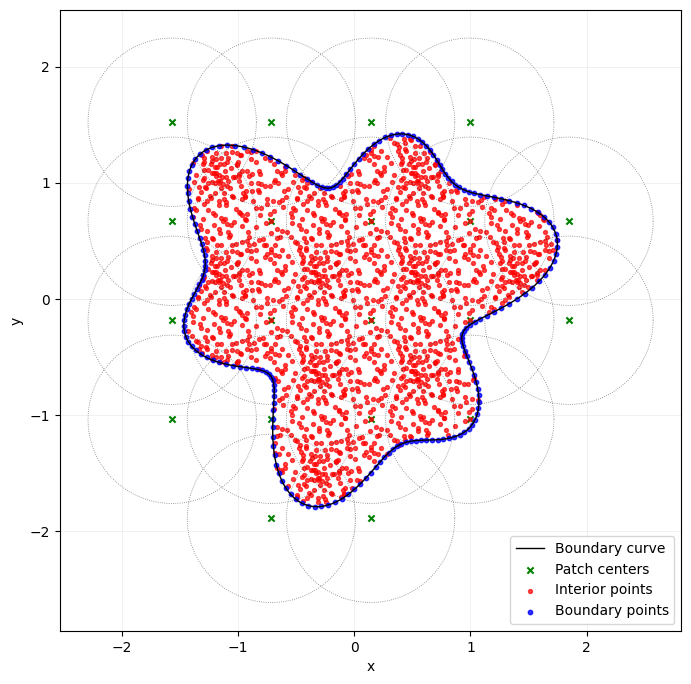

fill_distance of X: 0.08765277431593871
max |Zhat| = 0.9959328173299367
max |Yk_hat| = 0.9959328173299367
Compiling matrix time is: 2.97 seconds
||LI-I||_inf = 0.0001408208808941913
cond(LI) = 1.0002819771350608
cond(LBDF1) = 2.0461196991716476e+16
cond(LBDF2) = 4.092272873235914e+16
num eigvals: 1959
real min/max: -118613.58983030486 2435131750057.1694
imag min/max: -233382379.885552 233382379.885552
max |lambda|: 2435131750057.1694
min |lambda|: 0.999914401175749


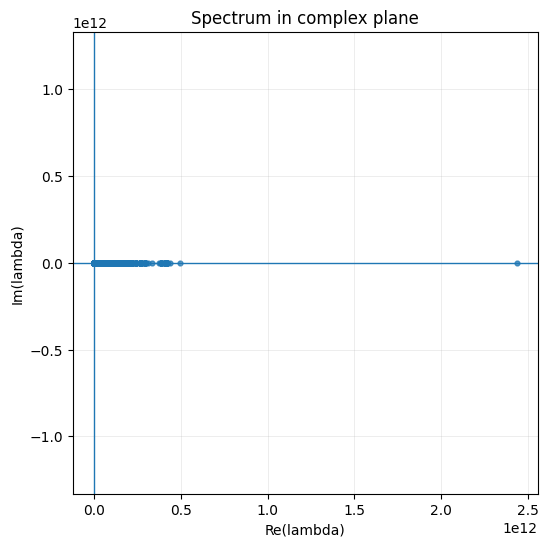

Solving linear system time is: 1.46 seconds
(1959, 201) (1959, 201)
p = 3; L infity error in u_rfmfd_pu: 4.264e-01
p = 3; Relative L2 error in u_rfmfd_pu: 1.139e-01
Time step 0, Relative L2 error: 0.000e+00
Time step 1, Relative L2 error: 0.000e+00
Time step 2, Relative L2 error: 1.236e-01
Time step 3, Relative L2 error: 1.235e-01
Time step 4, Relative L2 error: 1.234e-01
Time step 5, Relative L2 error: 1.233e-01
Time step 6, Relative L2 error: 1.232e-01
Time step 7, Relative L2 error: 1.231e-01
Time step 8, Relative L2 error: 1.230e-01
Time step 9, Relative L2 error: 1.229e-01
Time step 10, Relative L2 error: 1.228e-01
Time step 11, Relative L2 error: 1.228e-01
Time step 12, Relative L2 error: 1.227e-01
Time step 13, Relative L2 error: 1.226e-01
Time step 14, Relative L2 error: 1.225e-01
Time step 15, Relative L2 error: 1.224e-01
Time step 16, Relative L2 error: 1.223e-01
Time step 17, Relative L2 error: 1.222e-01
Time step 18, Relative L2 error: 1.221e-01
Time step 19, Relative L2 er

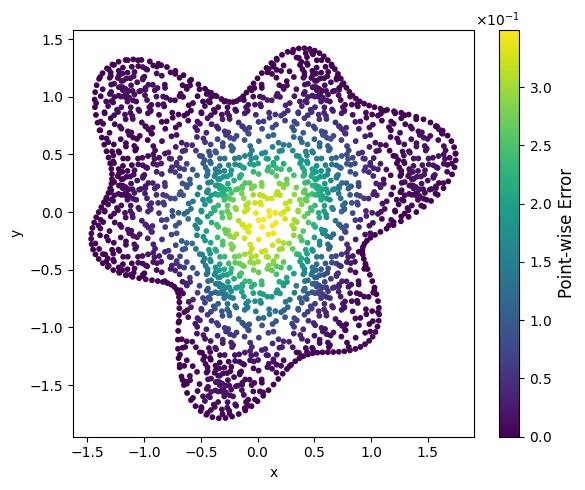

In [12]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

# out_n = 20
# Phi = PhiNet1(1,out_n).to(device) #
# Phi.initi()
# Phi = Phi.double()

hidden_size = 4
out_n = 2
Phi = PhiNet(1,hidden_size, out_n).to(device) #
Phi.initi()
Phi = Phi.double()

u_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
f_func = lambda x, y, t: np.sin(x) * np.cos(y) * np.exp(-t)
g_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
u0_func = lambda x, y : 1 + np.sin(x) * np.cos(y)

torchdtype = torch.float64
N_patch_grid = 5
# N_local_per_patch = 1000
# N_boundary = 8000
N_local_per_patch = 200
N_boundary = 200
# generate points
overlap = 0.2
X_inner, X_boundary, C, R , _ = generator_points_2d_overlap(N_patch_grid, N_local_per_patch, N_boundary, overlap, visu=True,)


# N_patch_grid = 5
# N_local_per_patch = 200
# N_boundary = 200
# R_ptch = 0.8
# # # generate points
# X_inner, X_boundary, ptch, _, _ = generator_points_star(N_patch_grid,N_local_per_patch,N_boundary,R_ptch)
# C = ptch['C']
# R = ptch['R']

X = np.vstack([X_inner, X_boundary])
Yin = X_inner
Yb = X_boundary
Y = np.vstack([Yin, Yb])
M1 = Yin.shape[0]
ptch = {
    "C": C,
    "R": R
}
#####
tau = 1e-3
T = 2e-1 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

order = 3
reg = 1e-13
u_true = u_func(Y[:,0:1], Y[:,1:2],t)
scheme = "BDF2"
# # ===========================================================
if order == 0:
    U,LBDF1,LBDF2,LI = rfm_fd_pum_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg)
else:
    U,LBDF1,LBDF2,LI = rfm_fd_pum_poly_solve_heat_scaled(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme=scheme)

    # U,L,LI = rfm_fd_pum_poly_solve_heat_scaled_RK4(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order)


print(U.shape, u_true.shape)
error = np.abs(U - u_true).max()#/np.abs(u_true + 1e-6)
# print(error)
if not np.isnan(error):
    print(f'p = {order}; L infity error in u_rfmfd_pu: {error.item():.3e}')
    error_u = np.linalg.norm(U - u_true, 2) / np.linalg.norm(u_true, 2)
    print(f'p = {order}; Relative L2 error in u_rfmfd_pu: {error_u.item():.3e}')

for i in range(Nt):
    err_time = np.linalg.norm(U[:,i].ravel() - u_true[:,i], 2) / np.linalg.norm(u_true[:,i], 2)
    print(f'Time step {i}, Relative L2 error: {err_time.item():.3e}')

UT = U[:,-1:].ravel()
u_true_T = u_true[:,-1:].squeeze(-1)

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UT - u_true_T), cmap='viridis', s=10)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
# plt.savefig(f'./result/p={order}_pointwise.eps', bbox_inches='tight')
plt.show()

In [7]:
def psi_b_1d(x):
    return np.where(
        x < -5.0/4.0, 0.0,
        np.where(
            x < -3.0/4.0,
            0.5 * (1.0 + np.sin(2.0 * np.pi * x)),
            np.where(
                x <= 3.0/4.0,
                1.0,
                np.where(
                    x <= 5.0/4.0,
                    0.5 * (1.0 - np.sin(2.0 * np.pi * x)),
                    0.0
                )
            )
        )
    )

def dpsi_b_1d(x):
    return np.where(
        x < -5.0/4.0, 0.0,
        np.where(
            x < -3.0/4.0,
            np.pi * np.cos(2.0 * np.pi * x),
            np.where(
                x <= 3.0/4.0,
                0.0,
                np.where(
                    x <= 5.0/4.0,
                    -np.pi * np.cos(2.0 * np.pi * x),
                    0.0
                )
            )
        )
    )

def d2psi_b_1d(x):
    return np.where(
        x < -5.0/4.0, 0.0,
        np.where(
            x < -3.0/4.0,
            -2.0 * np.pi**2 * np.sin(2.0 * np.pi * x),
            np.where(
                x <= 3.0/4.0,
                0.0,
                np.where(
                    x <= 5.0/4.0,
                    2.0 * np.pi**2 * np.sin(2.0 * np.pi * x),
                    0.0
                )
            )
        )
    )
def psi_b_2d_with_derivatives(Y, C, R):
    """
    Y: (M, 2)
    C: (Nc, 2)
    R: (Nc,) or (Nc, 2)
    Returns:
        psi:     (M, Nc)
        psi_x:   (M, Nc)
        psi_y:   (M, Nc)
        lap_psi: (M, Nc)
    """
    Y = np.asarray(Y)
    C = np.asarray(C)
    R = np.asarray(R)
    if R.ndim == 1:
        Rx = R[None, :]
        Ry = R[None, :]
    else:
        Rx = R[:, 0][None, :]
        Ry = R[:, 1][None, :]
    xhat = (Y[:, [0]] - C[:, 0][None, :]) / Rx
    yhat = (Y[:, [1]] - C[:, 1][None, :]) / Ry
    px = psi_b_1d(xhat)
    py = psi_b_1d(yhat)
    dpx = dpsi_b_1d(xhat) / Rx
    dpy = dpsi_b_1d(yhat) / Ry
    d2px = d2psi_b_1d(xhat) / (Rx**2)
    d2py = d2psi_b_1d(yhat) / (Ry**2)
    psi = px * py
    psi_x = dpx * py
    psi_y = px * dpy
    lap_psi = d2px * py + px * d2py
    return psi, psi_x, psi_y, lap_psi

def shepard_weights_PsiB_with_derivatives(Y, patch_C, patch_R, eps=1e-14):
    psi, psi_x, psi_y, lap_psi = psi_b_2d_with_derivatives(
        Y, patch_C, patch_R
    )
    S = np.sum(psi, axis=1, keepdims=True)
    Sx = np.sum(psi_x, axis=1, keepdims=True)
    Sy = np.sum(psi_y, axis=1, keepdims=True)
    LapS = np.sum(lap_psi, axis=1, keepdims=True)
    S = S + eps
    W = psi / S
    Wx = (psi_x * S - psi * Sx) / S**2
    Wy = (psi_y * S - psi * Sy) / S**2
    LapW = (
        lap_psi / S
        - psi * LapS / S**2
        - 2.0 * (psi_x * Sx + psi_y * Sy) / S**2
        + 2.0 * psi * (Sx**2 + Sy**2) / S**3
    )
    return W, Wx, Wy, LapW

def rfm_fd_pum_poly_solve_heat_scaled_RK4(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order):
    """
    ptch: patch center and each radius
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    t: [0:tau:T] tau: step length
    f_func, g_func, u_0func: Python callable returning torch tensor
    order: polynomial order (1,2,3,...)
    """
    patch_C = ptch['C']
    patch_R = ptch['R']
    Nc = patch_C.shape[0]
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]
    W_matrix,grad_Wx, grad_Wy, lap_W = shepard_weights_with_derivatives(Y, patch_C, patch_R)  # M x Nc
    # W_matrix, grad_Wx, grad_Wy, lap_W = shepard_weights_PsiB_with_derivatives(Y, patch_C, patch_R, eps=1e-14)
    # Construct sparse L matrix
    LI = lil_matrix((M, N))
    L = lil_matrix((M, N))
    # Precompute RHS
    f_val = f_func(Yin[:,0:1], Yin[:,1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:,0:1], Yb[:,1:2], t) if callable(g_func) else g_func
    u0 = u0_func(Y[:,0:1], Y[:,1:2]) if callable(u0_func) else u0_func[:, None]

    # --------------------------
    # --------------------------
    dist_XC = cdist(X, patch_C)      # (N, Nc)
    print("fill_distance of X:", fill_distance(X))
    print("CFL condition is, tau <= ", fill_distance(X)**2/4)
    dist_YC = cdist(Y, patch_C)      # (M, Nc)

    damp = reg
    row_scale = True
    col_scale = False

    time_start = time.time()
    # --------------------------------------------------
    for i in range(Nc):
        idx_X = np.where(dist_XC[:, i] <= patch_R[i])[0]
        idx_Y = np.where(dist_YC[:, i] <= patch_R[i])[0]
        idx_Yin = idx_Y[idx_Y < M1]
        idx_Yb = idx_Y[idx_Y >= M1]

        Mk,Mk_1 = idx_Y.shape[0],idx_Yin.shape[0]
        Yk_in,Yk_b = Y[idx_Yin],Y[idx_Yb]
        Yk = Y[idx_Y]
        nj = idx_X.shape[0]
        RHS_lap = np.zeros((nj+Norder,Mk_1)) # only need interior points
        RHS_ide = np.ones((nj+Norder,Mk))
        AP = np.zeros((nj+Norder,nj+Norder))
        P = np.ones((nj,Norder))

        Z = X[idx_X] # (nj,2)
        h_local = patch_R[i]
        xc = patch_C[i]
        Zhat = (Z - xc[None, :]) / h_local
        Yk_hat = (Yk - xc[None, :]) / h_local
        Yk_in_hat = (Yk_in - xc[None, :]) / h_local
        if i == 0:
            print("max |Zhat| =", np.max(np.linalg.norm(Zhat, axis=1)))
            print("max |Yk_hat| =", np.max(np.linalg.norm(Yk_hat, axis=1)))

        dist_ZZ = distance.cdist(Zhat, Zhat, metric='euclidean') # (nj,nj)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ).reshape(nj,-1)   #   (nj, nj * out_n * 2) # (nj,nj)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        Phi_reg = Phi_jj @ Phi_jj.T + reg * np.eye(nj)

        if Yk_hat.shape[0] * Zhat.shape[0] >= 2e5:
            phi_YX, lap_phi, grad_y = laplacian_phi_wrt_y_chunked(Phi, Yk_hat, Zhat, chunk_size=800)
        else:
            phi_YX, lap_phi, grad_y  = laplacian_phi_wrt_y(Phi, Yk_hat, Zhat) # (Mk,nj)
        lap_phi = lap_phi/ (h_local)**2
        grad_y = grad_y/ h_local
        
        # grad_phi_x = grad_y[:, :, 0].T  # (nj,Mk)
        # grad_phi_y = grad_y[:, :, 1].T  # (nj,Mk) (Mk,nj) 
        # AP
        P = poly2D(Zhat, order)  # (nj,Norder)
        AP[:nj,:] = np.concatenate([Phi_reg,P], axis = 1) # (nj,nj+Norder)
        AP[nj:,:-Norder] = P.T # (Norder,nj)
        ## --- RHS_lap(Yin), RHS_ide(Y)
        lap_p = laplacian_poly2D(order,Yk_in_hat) # (Norder, Mk_1)
        lap_p = lap_p/ (h_local**2)
        p_y = poly2D(Yk_hat, order).T       # (Mk,Norder).T = (Norder,Mk)
        lap_phi = lap_phi[:Mk_1,:]      # (Mk,nj) --> (Mk_1,nj)
        RHS_lap[:nj,:] = Phi_jj @ lap_phi.T      # (nj, Mk_1), Yk_in
        RHS_lap[nj:,:] = lap_p          # (Norder, Mk_1)
        RHS_ide[:nj,:] = Phi_jj @ phi_YX.T       # (Mk,nj).T 
        RHS_ide[nj:,:] = p_y            # (Norder, Mk)
        # --- RHS_gra_x(Yin), RHS_gra_z(Yin)
        # p_x,p_z = gradient_poly2D(order, Yk_in_hat)  # (Norder,Mk_1)
        # p_x = p_x / h_local
        # p_z = p_z / h_local
        # RHS_gra_x = np.zeros((nj+Norder,Mk_1))  # (nj+Norder, Mk_1)
        # RHS_gra_z = np.zeros((nj+Norder,Mk_1))  # (nj+Norder, Mk_1)
        # RHS_gra_x[:nj,:] = grad_phi_x[:,:Mk_1]  # (nj, Mk_1)
        # RHS_gra_z[:nj,:] = grad_phi_y[:,:Mk_1]  # (nj, Mk_1)
        # RHS_gra_x[nj:,:] = p_x                  # (Norder, Mk_1)
        # RHS_gra_z[nj:,:] = p_z                  # (Norder, Mk_1)

        # --- w_lap, w_ide
        # AP = AP + reg * np.eye(nj + Norder)
 
        RHS_all = np.concatenate([RHS_ide, RHS_lap],axis=1)
        # RHS_all = np.concatenate([RHS_ide, RHS_lap, RHS_gra_x, RHS_gra_z],axis=1)

        # W_all = lstsq(AP, RHS_all, cond=reg)[0]  # (nj + Norder, 4*Mk_1)
        AP_factor = damped_lstsq_qr_factor(AP, damp = damp, row_scale = row_scale, col_scale = col_scale)
        W_all = damped_lstsq_qr_solve(AP_factor,RHS_all,print_residual=True)
        # print(f"residual is, {np.linalg.norm(AP @ W_all - RHS_all)}")
        w_ide    = W_all[:, 0:Mk]                # (nj + Norder, Mk)
        w_lap    = W_all[:, Mk:Mk+Mk_1]          # (nj + Norder, Mk_1)
        # print("w_lap.max is", np.linalg.norm(w_lap,ord=np.inf))
        # print("w_ide.max is", np.linalg.norm(w_ide,ord=np.inf))

        # w_grad_x = W_all[:, Mk+Mk_1:Mk+2*Mk_1]   # (nj + Norder, Mk_1)
        # w_grad_z = W_all[:, Mk+2*Mk_1:]          # (nj + Norder, Mk_1)
        # --- Shepard weight. W_matrix,grad_Wx, grad_Wy, lap_W , M x Nc
        win = W_matrix[idx_Yin,i][None, :]    # (1, Mk_1)
        # win_gradx = grad_Wx[idx_Yin,i][None, :]  # (1, Mk_1)
        # win_gradz = grad_Wy[idx_Yin,i][None, :]  # (1, Mk_1)
        # win_lap = lap_W[idx_Yin,i][None, :]      # (1, Mk_1)
        Laplace =  win * w_lap[:nj,:Mk_1]
        # Laplace = (2 * win_gradx * w_grad_x[:nj,:Mk_1] + 2 * win_gradz * w_grad_z[:nj,:Mk_1] + win * w_lap[:nj,:Mk_1] + win_lap * w_ide[:nj,:Mk_1])  # (nj, Mk_1)
        I = win * w_ide[:nj,:Mk_1]          # (nj, Mk_1)
        # --- boundary condtion
        wbc = W_matrix[idx_Yb,i][None, :]  # (1, Mk_2)
        Op_bc = wbc * w_ide[:nj,Mk_1:]        # (nj, Mk_2)

        # --- Iterative Matrix
        LI[np.ix_(idx_Yin, idx_X)] = LI[np.ix_(idx_Yin, idx_X)] + I.T
        L[np.ix_(idx_Yin, idx_X)] = L[np.ix_(idx_Yin, idx_X)] + Laplace.T
        LI[np.ix_(idx_Yb, idx_X)] = LI[np.ix_(idx_Yb, idx_X)] + Op_bc.T
        L[np.ix_(idx_Yb, idx_X)] = L[np.ix_(idx_Yb, idx_X)] + Op_bc.T

    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    time_end = time.time()
    print(f"Compiling matrix time is: {time_end - time_start:.2f} seconds")
    
    U = np.zeros((M, NT))
    U[:,0:1] = u0   # (N,1)
    U[M1:,:] = g_val
    LI = LI.tocsr()
    L = L.tocsr()

    if N<= 1e4:
        LI_dense = LI.toarray()
        L_dense = L.toarray()
        A = L_dense @ np.linalg.inv(LI_dense)
        Aii = A[:M1, :M1]
        eig = np.linalg.eigvals(Aii)
        print("max real eig =", np.max(eig.real))
        print("min real eig =", np.min(eig.real))
        print("max abs eig =", np.max(np.abs(eig)))
        print("tau * max abs eig <= 2.785, now is ", tau * np.max(np.abs(eig)))
        cond_LI = np.linalg.cond(LI.todense())
        print("cond(LI) =", cond_LI)
        cond_L= np.linalg.cond(L.todense())
        print("cond(L) =", cond_L)


    time_start = time.time()
    if M == N:
        LI_factor = damped_lstsq_qr_factor(LI, damp = damp, row_scale = row_scale, col_scale = col_scale)
        def rhs(L, U_stage, tt):
            """
            Compute k = F(U_stage, tt).
            """
            U_stage = U_stage.copy()
            # boundary value at this RK stage
            U_stage[M1:, :] = g_func(Yb[:, 0:1], Yb[:, 1:2], tt)
            alpha_stage = damped_lstsq_qr_solve(LI_factor,U_stage,print_residual=True)
            # alpha_stage = scipy.linalg.lstsq(LI.toarray(), U_stage, cond=1e-10, lapack_driver="gelsd")[0]
            print(f"residual is, {np.linalg.norm(LI @ alpha_stage - U_stage)}")
            k = np.zeros_like(U_stage)
            # interior evolution
            k[:M1, :] = (L[:M1, :] @ alpha_stage + f_func(Yin[:, 0:1], Yin[:, 1:2], tt))
            # boundary is imposed directly, not evolved by PDE
            k[M1:, :] = 0.0
            return k

        for n in range(NT - 1):
            tn = t[n]
            Un = U[:, n:n+1].copy()
            k1 = rhs(L, Un, tn)
            U_half_1 = Un + 0.5 * tau * k1
            k2 = rhs(L, U_half_1, tn + 0.5 * tau)
            U_half_2 = Un + 0.5 * tau * k2
            k3 = rhs(L, U_half_2, tn + 0.5 * tau)
            U_full = Un + tau * k3
            k4 = rhs(L, U_full, tn + tau)
            U_next = Un + (tau / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
            # enforce boundary exactly at t_{n+1}
            U_next[M1:, :] = g_func(Yb[:, 0:1], Yb[:, 1:2], tn + tau)
            U[:, n+1:n+2] = U_next        
    else:
        print("M is not equal to N. Please use QR.")
    
    time_end = time.time()
    print(f"Solving linear system time is: {time_end - time_start:.2f} seconds")
    return U,L,LI



In [8]:
class PhiNet1(nn.Module):
    def __init__(self, input_size=1, output_size=5):
        super(PhiNet1, self).__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, output_size, bias = True)
        self.aj = nn.Parameter(torch.randn(output_size))

    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.unsqueeze(-1)

        output1 = torch.cos(self.input_layer(x))
        output2 = torch.sin(self.input_layer(x))
        aj_ = torch.sqrt(torch.nn.functional.softplus(self.aj))
        output = torch.cat((output1*aj_, output2 * aj_),dim = -1)   
        return output

    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                # nn.init.uniform_(m.weight, a = -1, b = 1)
                if m.bias is not None:
                    # nn.init.uniform_(m.bias, -torch.pi, torch.pi)
                     nn.init.uniform_(m.bias, -1, 1)


class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = False)

    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        output = torch.exp(-(5.254967247093529)**2 * x**2)
        # output = torch.sigmoid(self.input_layer(x))
        # output = torch.cos(self.output_layer(output))
        if output.shape[0] != K: 
            output = output.view(K, -1)
        return output

    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                # nn.init.uniform_(m.weight, a = -1, b = 1)
                if m.bias is not None:
                    # nn.init.uniform_(m.bias, -torch.pi, torch.pi)
                     nn.init.uniform_(m.bias, -1, 1)


Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 20
removed patches: 5
patch nX min/mean/max: 15 / 222.05 / 498
X_inner: 1759
X_boundary: 1000
cover X_inner min/mean/max: 1 2.52 4 uncovered: 0
cover X_all min/mean/max: 1 2.39 4 uncovered: 0


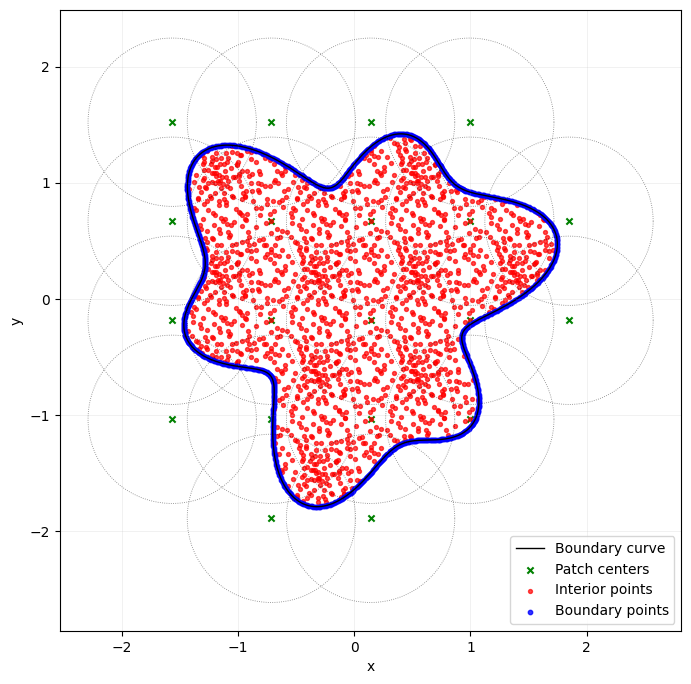

fill_distance of X: 0.08765277431593871
CFL condition is, tau <=  0.001920752211320221
max |Zhat| = 0.9959328173299367
max |Yk_hat| = 0.9959328173299367
Least Square Relative residual: 7.8426e-11
Least Square Relative residual: 5.4664e-11
Least Square Relative residual: 5.8840e-11
Least Square Relative residual: 6.4299e-11
Least Square Relative residual: 5.0097e-11
Least Square Relative residual: 5.6368e-11
Least Square Relative residual: 5.0226e-11
Least Square Relative residual: 4.8383e-11
Least Square Relative residual: 6.2503e-11
Least Square Relative residual: 5.7863e-11
Least Square Relative residual: 5.3120e-11
Least Square Relative residual: 5.5977e-11
Least Square Relative residual: 5.4068e-11
Least Square Relative residual: 8.8652e-11
Least Square Relative residual: 5.7611e-11
Least Square Relative residual: 5.4779e-11
Least Square Relative residual: 5.2059e-11
Least Square Relative residual: 8.2251e-11
Least Square Relative residual: 6.6548e-11
Least Square Relative residual

/home/chengwu/.conda/envs/py312/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/tmp/ipykernel_77872/1351699722.py:83: RuntimeWarning: invalid value encountered in scalar divide
  res_aug_rel = num / den if den != 0 else np.nan


Least Square Relative residual: 0.0000e+00
residual is, 3.923900569904067e+149
Least Square Relative residual: 0.0000e+00
residual is, 2.7851326460424985e+150
Least Square Relative residual: nan
residual is, 3.5051879364892606e+151
Least Square Relative residual: nan
residual is, 6.626993493314223e+151
Least Square Relative residual: nan
residual is, 3.7374737248226654e+152
Least Square Relative residual: nan
residual is, 2.476859359545024e+153
Least Square Relative residual: nan
residual is, inf
Least Square Relative residual: nan
residual is, inf
Least Square Relative residual: nan
residual is, inf
Least Square Relative residual: nan
residual is, inf
Least Square Relative residual: nan
residual is, inf
Least Square Relative residual: nan
residual is, inf
Least Square Relative residual: nan
residual is, inf
Least Square Relative residual: nan
residual is, inf
Least Square Relative residual: nan
residual is, inf
Least Square Relative residual: nan
residual is, inf
Least Square Relative

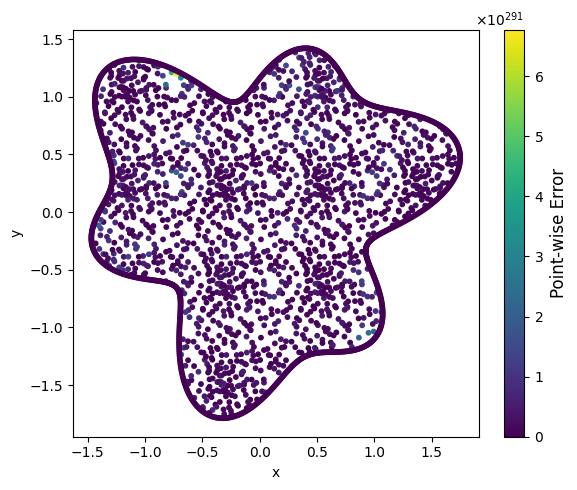

In [9]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

# out_n = 2
# Phi = PhiNet1(1,out_n).to(device) #
# Phi.initi()
# Phi = Phi.double()

hidden_size = 20
out_n = 2
Phi = PhiNet(1,hidden_size, out_n).to(device) #
Phi.initi()
Phi = Phi.double()

# # # ===========================================================
# u_func = lambda x, y, t: 1 + np.sin(pi * x) * np.cos(pi * y) * np.exp(-pi * t)
# f_func = lambda x, y, t: (2* pi**2 -1) * np.sin(pi * x) * np.cos(pi * y) * np.exp(-pi * t)
# g_func = lambda x, y, t: 1 + np.sin(pi * x) * np.cos(pi * y) * np.exp(-pi * t)
# u0_func = lambda x, y : 1 + np.sin(pi * x) * np.cos(pi * y)

# # ===========================================================
u_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
f_func = lambda x, y, t: np.sin(x) * np.cos(y) * np.exp(-t)
g_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
u0_func = lambda x, y : 1 + np.sin(x) * np.cos(y)

torchdtype = torch.float64
N_patch_grid = 5
N_local_per_patch = 200
N_boundary = 1000
# generate points
overlap = 0.2

X_inner, X_boundary, C, R , _ = generator_points_2d_overlap(N_patch_grid, N_local_per_patch, N_boundary, overlap, visu=True,)
X = np.vstack([X_inner, X_boundary])
Yin = X_inner
Yb = X_boundary
Y = np.vstack([Yin, Yb])
M1 = Yin.shape[0]
ptch = {
    "C": C,
    "R": R
}
#####
tau = 1e-5
T = 1e-3 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

order = 0
reg = 1e-12
u_true = u_func(Y[:,0:1], Y[:,1:2],t)
scheme = "BDF2"
# # ===========================================================
if order == 0:
    # U,LBDF1,LBDF2,LI = rfm_fd_pum_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg)
# else:
    # U,LBDF1,LBDF2,LI = rfm_fd_pum_poly_solve_heat_scaled(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme=scheme)
    U,L,LI = rfm_fd_pum_poly_solve_heat_scaled_RK4(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order)

# print(U.shape, u_true.shape)
error = np.abs(U - u_true)#/np.abs(u_true + 1e-6)
# print(error)
print(f'p = {order}; L infity error in u_rfmfd_pu: {error.max().item():.3e}')
error_u = np.linalg.norm(U - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'p = {order}; Relative L2 error in u_rfmfd_pu: {error_u.item():.3e}')

for i in range(Nt):
    err_time = np.linalg.norm(U[:,i].ravel() - u_true[:,i], 2) / np.linalg.norm(u_true[:,i], 2)
    print(f'Time step {i}, Relative L2 error: {err_time.item():.3e}')

UT = U[:,-1:].ravel()
u_true_T = u_true[:,-1:].squeeze(-1)

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UT - u_true_T), cmap='viridis', s=10)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
# plt.savefig(f'./result/p={order}_pointwise.eps', bbox_inches='tight')
plt.show()

# 画收敛阶段图

Run Q=1, N_local_per_patch=15
Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 19
removed patches: 6
patch nX min/mean/max: 4 / 17.58 / 38
X_inner: 128
X_boundary: 25
cover X_inner min/mean/max: 1 2.61 4 uncovered: 0
cover X_all min/mean/max: 1 2.52 4 uncovered: 0
X.shape 153
fill_distance of X: 0.3861706195083577
max |Zhat| = 0.9428090415820634
max |Yk_hat| = 0.9428090415820634
Least Square Relative residual: 5.5313e-07
Least Square Relative residual: 5.1830e-07
Least Square Relative residual: 5.5823e-07
Least Square Relative residual: 6.3536e-07
Least Square Relative residual: 5.3586e-07
Least Square Relative residual: 4.7401e-07
Least Square Relative residual: 4.5086e-07
Least Square Relative residual: 5.6207e-07
Least Square Relative residual: 6.9419e-07
Least Square Relative residual: 4.9825e-07
Least Square Relative residual: 4.6614e-07
Least Square Relative residual: 4.7216e-07
Least Square Relative residual: 6.1005e-07
Least Square Rel

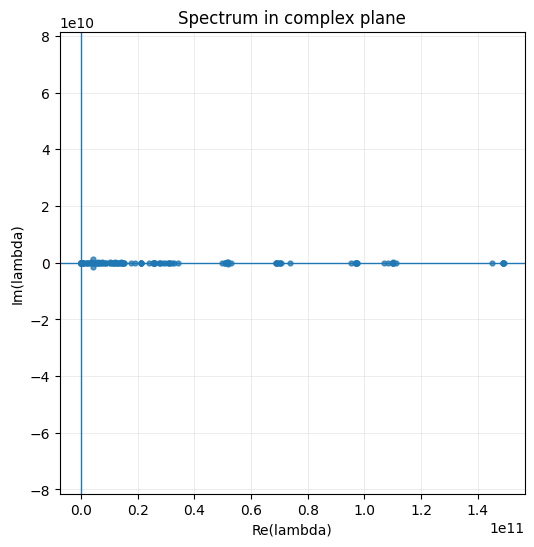

residual is: 0.00025646217589202653
residual is: 0.00021837348990475858
residual is: 0.0002655406094323474
residual is: 0.00020293971798507758
residual is: 0.0002162338144506732
residual is: 0.00023451201061905341
residual is: 0.00023231497890102313
residual is: 0.00024826725277840014
residual is: 0.00020613089809350322
residual is: 0.00026691219731691694
residual is: 0.00020645071100486192
residual is: 0.0002019383071299677
residual is: 0.0002494510938688986
residual is: 0.0002648515540719978
residual is: 0.000291723387434618
residual is: 0.0002471879305808382
residual is: 0.00020342209239498915
residual is: 0.0002357497234876515
residual is: 0.0002792423838805626
residual is: 0.0002348455192829696
residual is: 0.00024718660393950766
residual is: 0.00023777382935770902
residual is: 0.00020978072001570376
residual is: 0.00020037592263377524
residual is: 0.0002891970006167057
residual is: 0.00023337254349318275
residual is: 0.00025870617037135427
residual is: 0.00023985221421706304
resi

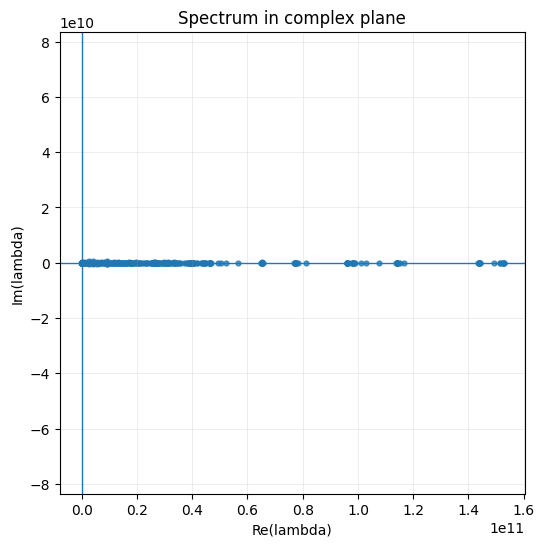

residual is: 0.00037081180110908355
residual is: 0.00027203760061679657
residual is: 0.0004236865413610245
residual is: 0.00029549314779034314
residual is: 0.0002976147925596312
residual is: 0.00030298396041890613
residual is: 0.0003234630553227144
residual is: 0.00032846839318760644
residual is: 0.00030221299530942716
residual is: 0.00029587970840986677
residual is: 0.0003428166631448779
residual is: 0.0003281175806716944
residual is: 0.000291324425370809
residual is: 0.000344551333218312
residual is: 0.000276247564366206
residual is: 0.00029969794927181916
residual is: 0.0002965625263076188
residual is: 0.0002837473100168986
residual is: 0.00028981236039648704
residual is: 0.0003137272621508253
residual is: 0.00029310945120274737
residual is: 0.00027087310595845065
residual is: 0.000316343806731812
residual is: 0.0003093070658426548
residual is: 0.0003172226027351176
residual is: 0.0003158085720345457
residual is: 0.0003331476655826928
residual is: 0.0002996023800827372
residual is: 

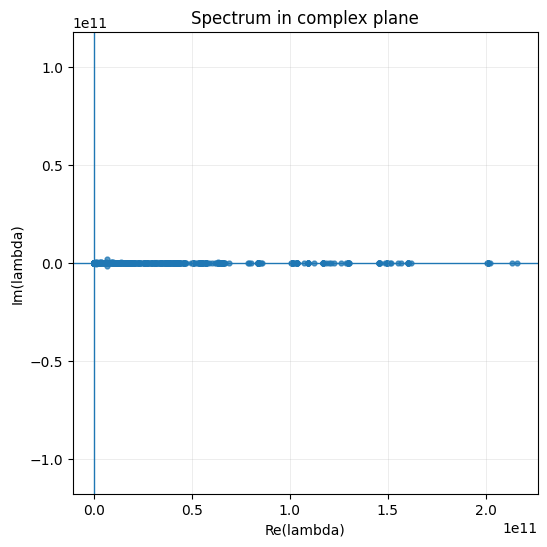

residual is: 0.0009206271726976353
residual is: 0.0009555416720883588
residual is: 0.0007976760417966321
residual is: 0.0009642228451471346
residual is: 0.0008590351541069131
residual is: 0.000825654845110919
residual is: 0.0008524480867831404
residual is: 0.0009736101873568458
residual is: 0.0007783334248515466
residual is: 0.000869162414164976
residual is: 0.0008282064743927045
residual is: 0.0008024246720993193
residual is: 0.0008015264461098138
residual is: 0.0009596227846212891
residual is: 0.0009563470470718117
residual is: 0.0011281248058873671
residual is: 0.0007987282067710173
residual is: 0.0009685713029482299
residual is: 0.0008554969808554569
residual is: 0.000806353951930505
residual is: 0.0009554981645304371
residual is: 0.0008752066329569926
residual is: 0.000916737925269226
residual is: 0.0009309704222190997
residual is: 0.0009716424932016523
residual is: 0.0009319872953665089
residual is: 0.0008491901969690769
residual is: 0.0009590165277060975
residual is: 0.000933651

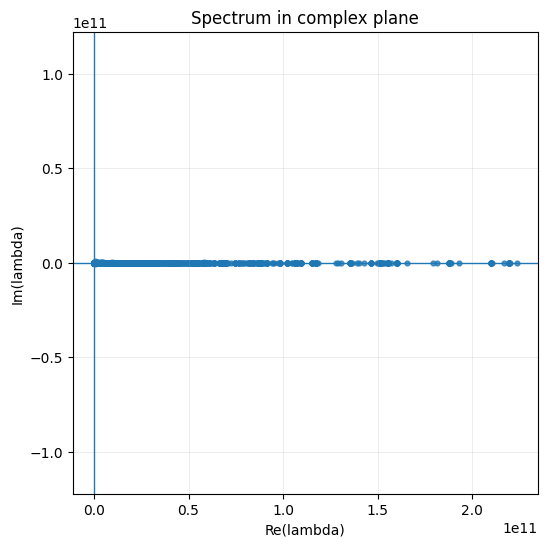

residual is: 0.004127112580970569
residual is: 0.0036951168079337724
residual is: 0.0035172707340205907
residual is: 0.004150229863459894
residual is: 0.004481835158375485
residual is: 0.003801866303847066
residual is: 0.003675907373821005
residual is: 0.003803767897060188
residual is: 0.004205856351375357
residual is: 0.004007765067724863
residual is: 0.004525854058003933
residual is: 0.004092284989872781
residual is: 0.004147710257518982
residual is: 0.004209500268172026
residual is: 0.0036518650668103804
residual is: 0.0038317555618748236
residual is: 0.003988384157477729
residual is: 0.004264085352732815
residual is: 0.004175423352087434
residual is: 0.0038390800243643993
residual is: 0.003950389795027293
residual is: 0.003407240905647346
residual is: 0.004008854515858375
residual is: 0.004235568518066664
residual is: 0.003985006742647052
residual is: 0.004226945171583238
residual is: 0.0038808686809953456
residual is: 0.0044118397171134275
residual is: 0.0038106712784555926
residu

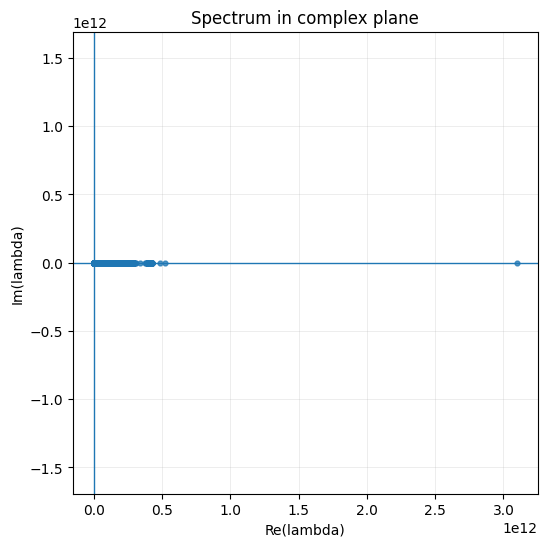

residual is: 0.008581739903819191
residual is: 0.01155427606310361
residual is: 0.009935551025002652
residual is: 0.008338774253286533
residual is: 0.009571969733998468
residual is: 0.009814898475379506
residual is: 0.009447416251826697
residual is: 0.009774110074580837
residual is: 0.011799557457133075
residual is: 0.010207655604257149
residual is: 0.00930137720516192
residual is: 0.009746030012551516
residual is: 0.00794248514359709
residual is: 0.009306210079048376
residual is: 0.008105365705429288
residual is: 0.010382555867658497
residual is: 0.00874185957586844
residual is: 0.00796863646161506
residual is: 0.008810619014438376
residual is: 0.010497131673204227
residual is: 0.010276933640237263
residual is: 0.009741775479646381
residual is: 0.011778036243775353
residual is: 0.009004763123112028
residual is: 0.010722828977733452
residual is: 0.008056867139324247
residual is: 0.009368819270839625
residual is: 0.00920952236367473
residual is: 0.008382980200021166
residual is: 0.00923

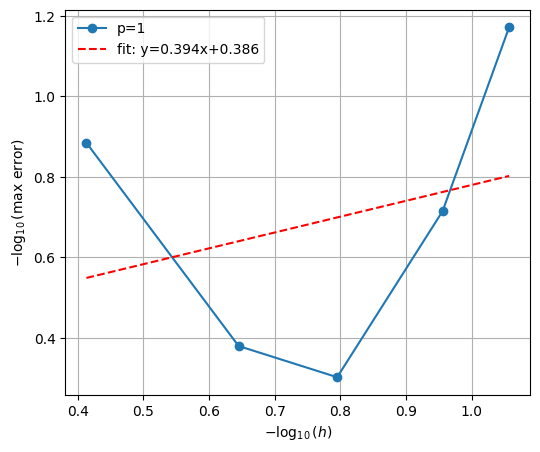

In [38]:
key = 100
np.random.seed(key)

NN = [15,30,50,80,200]
BC = [25,50,100,200,400]
H = np.zeros((5,len(NN)))
E = np.zeros((5,len(NN)))
tau = 1e-3
T = 0.2 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)
scheme = "BDF2"
RR = [1e-8,1e-12,1e-12,1e-12,1e-15]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = BC[qi]
    overlap = 0.2
    # generate points
    X_inner, X_boundary, C, R ,_ = generator_points_2d_overlap(
    N_patch_grid, N_local_per_patch, N_boundary, overlap, False)
    ptch = {
    "C": C,
    "R": R
    }
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 0
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    U,LBDF1,LBDF2,LI = rfm_fd_pum_poly_solve_heat_scaled(ptch, X, Yin, Yb, out_n, t, tau, f_func, g_func, u0_func, Phi, reg, order)
    error = np.max(np.abs(U - u_true))
    e = np.linalg.norm(U - u_true)/ np.linalg.norm(u_true)
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label='p=1')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=15
Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 19
removed patches: 6
patch nX min/mean/max: 4 / 17.58 / 38
X_inner: 128
X_boundary: 25
cover X_inner min/mean/max: 1 2.61 4 uncovered: 0
cover X_all min/mean/max: 1 2.52 4 uncovered: 0
X.shape 153
fill_distance of X: 0.3861706195083577
max |Zhat| = 0.9428090415820634
max |Yk_hat| = 0.9428090415820634
Least Square Relative residual: 5.0792e-11
Least Square Relative residual: 4.9667e-11
Least Square Relative residual: 4.8214e-11
Least Square Relative residual: 5.6277e-11
Least Square Relative residual: 4.9363e-11
Least Square Relative residual: 4.7213e-11
Least Square Relative residual: 4.4831e-11
Least Square Relative residual: 5.3997e-11
Least Square Relative residual: 6.5877e-11
Least Square Relative residual: 4.9244e-11
Least Square Relative residual: 4.6461e-11
Least Square Relative residual: 4.7031e-11
Least Square Relative residual: 5.8336e-11
Least Square Rel

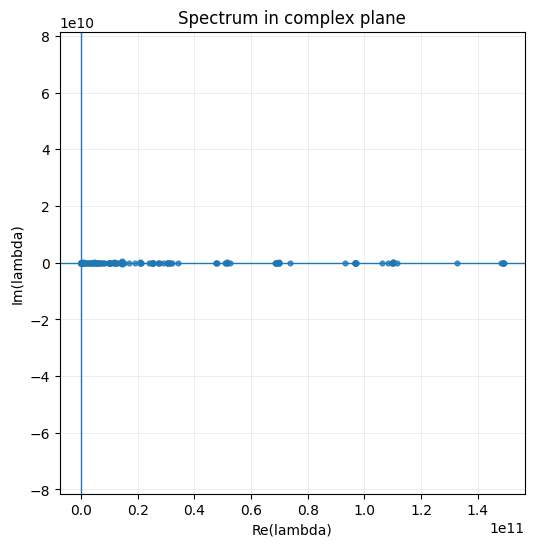

residual is: 0.00015714813494873854
residual is: 0.00019569338306422296
residual is: 0.000145150349707421
residual is: 0.00015834484942508484
residual is: 0.00018890783519487204
residual is: 0.0001559420733828057
residual is: 0.0001517394781915315
residual is: 0.0001780466150589339
residual is: 0.0001502277248493275
residual is: 0.0001371491385093133
residual is: 0.00013620209858159025
residual is: 0.0001416920906431592
residual is: 0.00017263575970680054
residual is: 0.0001401845287186305
residual is: 0.00017315046039382818
residual is: 0.00013719338202716324
residual is: 0.00016300534407149065
residual is: 0.00014879705739235502
residual is: 0.00016458885676696162
residual is: 0.00014385867749504308
residual is: 0.00015563564553536764
residual is: 0.00019158325257968687
residual is: 0.0001526519545620964
residual is: 0.0001635269817460793
residual is: 0.00020442570205237836
residual is: 0.00011953011955491518
residual is: 0.00016738563828536492
residual is: 0.00018458017244784542
res

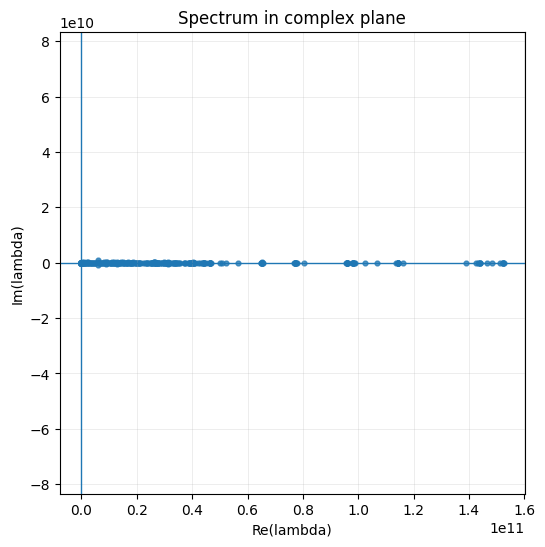

residual is: 0.00025551280617684317
residual is: 0.00028868758796998323
residual is: 0.00025259383964938486
residual is: 0.00031144474221810476
residual is: 0.0003414720676087636
residual is: 0.0002780062428743637
residual is: 0.0003266252632013207
residual is: 0.0003058609444101103
residual is: 0.00031325026105815355
residual is: 0.0003243804132541399
residual is: 0.00032806417890029555
residual is: 0.0002714738523121272
residual is: 0.00030948504944732527
residual is: 0.000290183427846422
residual is: 0.0003001164392728569
residual is: 0.00027716347251245
residual is: 0.0003154542876887453
residual is: 0.000282336871468954
residual is: 0.0003247105087025243
residual is: 0.000268718519446641
residual is: 0.00026487572871152995
residual is: 0.00028460139502729304
residual is: 0.0002941751875429035
residual is: 0.000287963488039952
residual is: 0.00029585813840456247
residual is: 0.0002796418716190913
residual is: 0.000292325856938556
residual is: 0.0003078811998209113
residual is: 0.00

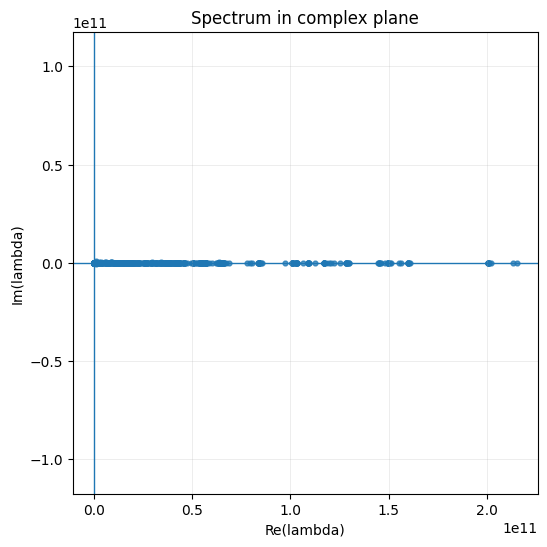

residual is: 0.001137066979724824
residual is: 0.0011749024809985075
residual is: 0.0010411740267016892
residual is: 0.0013829552632708714
residual is: 0.0010598980647221839
residual is: 0.0010872653491469523
residual is: 0.0010208374211477039
residual is: 0.0009246109825110471
residual is: 0.001004960830040099
residual is: 0.0011052481073139907
residual is: 0.0011246307220689204
residual is: 0.001136100008249721
residual is: 0.0011929955715273004
residual is: 0.0013430150497027538
residual is: 0.000941108345211516
residual is: 0.0009658614347866802
residual is: 0.0010927393331254612
residual is: 0.0010236226321207811
residual is: 0.0009940392383709004
residual is: 0.0010643090312885356
residual is: 0.0014437057230995644
residual is: 0.0012322122741679881
residual is: 0.001031694316798868
residual is: 0.0011082113320770766
residual is: 0.0010087739794528176
residual is: 0.0010248006325800669
residual is: 0.0010838780544370483
residual is: 0.0011174197231577628
residual is: 0.0011782054

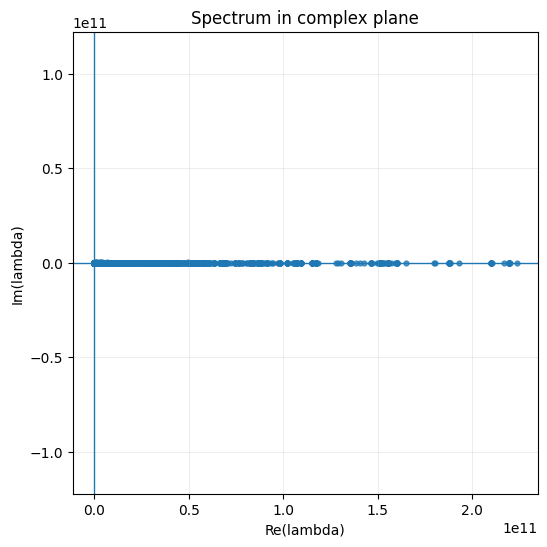

residual is: 0.0038219224657698296
residual is: 0.004510939879732457
residual is: 0.006247790783544859
residual is: 0.004142657316314043
residual is: 0.0038516839036488834
residual is: 0.005177477181522664
residual is: 0.004830917036627739
residual is: 0.004368696709918643
residual is: 0.0050465234146478116
residual is: 0.0048574830520576465
residual is: 0.005100098430767656
residual is: 0.004487661341914022
residual is: 0.003995871397773983
residual is: 0.005872829696574705
residual is: 0.004799845883038983
residual is: 0.005389403173543988
residual is: 0.004361411639362149
residual is: 0.0042696605872773385
residual is: 0.004751071437577487
residual is: 0.00397566638872901
residual is: 0.004412164471224725
residual is: 0.004660505772954145
residual is: 0.0037481538208212852
residual is: 0.004988362179534534
residual is: 0.004011135418709042
residual is: 0.005956884097616803
residual is: 0.004378710093330572
residual is: 0.004872458018878343
residual is: 0.003885201551668672
residual 

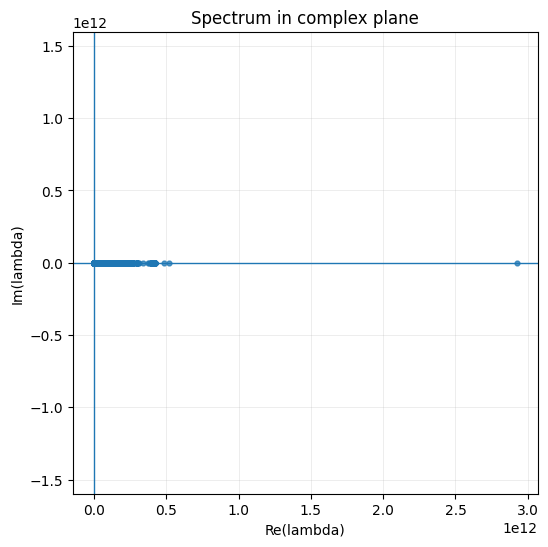

residual is: 0.010495706492173447
residual is: 0.010685905572923404
residual is: 0.009540697888727374
residual is: 0.01070282197776462
residual is: 0.011035128972194734
residual is: 0.011395393866552155
residual is: 0.0118640873310019
residual is: 0.010920605449613152
residual is: 0.011860640137121932
residual is: 0.010282282699325386
residual is: 0.011552154816960952
residual is: 0.010794303850000986
residual is: 0.01031898497626123
residual is: 0.010958095901743285
residual is: 0.009783684036588998
residual is: 0.012821408153991111
residual is: 0.01064682509701828
residual is: 0.01120212460565182
residual is: 0.012137015250259557
residual is: 0.012248809416855341
residual is: 0.010740234797293092
residual is: 0.013261196277884106
residual is: 0.011014438021678261
residual is: 0.009579564706894018
residual is: 0.012024670773090882
residual is: 0.014016595317880584
residual is: 0.010794790555718326
residual is: 0.009861535628823715
residual is: 0.00994544957283871
residual is: 0.012281

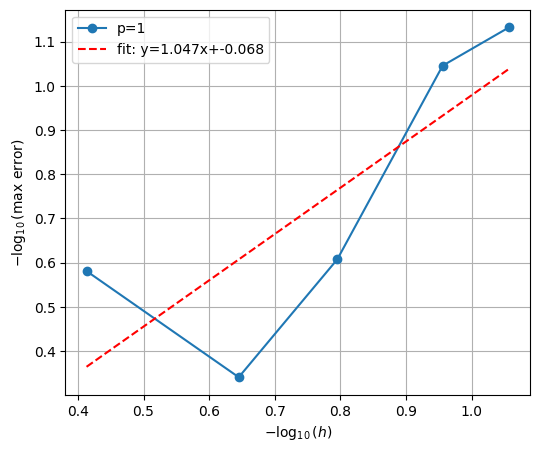

In [39]:
key = 100
np.random.seed(key)
# NN = [15,30,70,100,200]

NN = [15,30,50,80,200]
BC = [25,50,100,200,400]

tau = 1e-3
T = 0.2 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)
scheme = "BDF2"
RR = [1e-12,1e-12,1e-12,1e-12,1e-12]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = BC[qi]
    overlap = 0.2
    # generate points
    X_inner, X_boundary, C, R ,_ = generator_points_2d_overlap(
    N_patch_grid, N_local_per_patch, N_boundary, overlap, False)
    ptch = {
    "C": C,
    "R": R
    }
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 1
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    U,LBDF1,LBDF2,LI = rfm_fd_pum_poly_solve_heat_scaled(ptch, X, Yin, Yb, out_n, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme="BDF2")
    error = np.max(np.abs(U - u_true))
    e = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label='p=1')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=15
Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 19
removed patches: 6
patch nX min/mean/max: 4 / 17.58 / 38
X_inner: 128
X_boundary: 25
cover X_inner min/mean/max: 1 2.61 4 uncovered: 0
cover X_all min/mean/max: 1 2.52 4 uncovered: 0
X.shape 153
fill_distance of X: 0.3861706195083577
max |Zhat| = 0.9428090415820634
max |Yk_hat| = 0.9428090415820634
Least Square Relative residual: 4.5620e-11
Least Square Relative residual: 4.5851e-11
Least Square Relative residual: 2.1342e-11
Least Square Relative residual: 4.4742e-11
Least Square Relative residual: 4.6425e-11
Least Square Relative residual: 4.4242e-11
Least Square Relative residual: 4.2928e-11
Least Square Relative residual: 4.9335e-11
Least Square Relative residual: 5.8573e-11
Least Square Relative residual: 4.7042e-11
Least Square Relative residual: 4.3965e-11
Least Square Relative residual: 4.4185e-11
Least Square Relative residual: 5.0085e-11
Least Square Rel

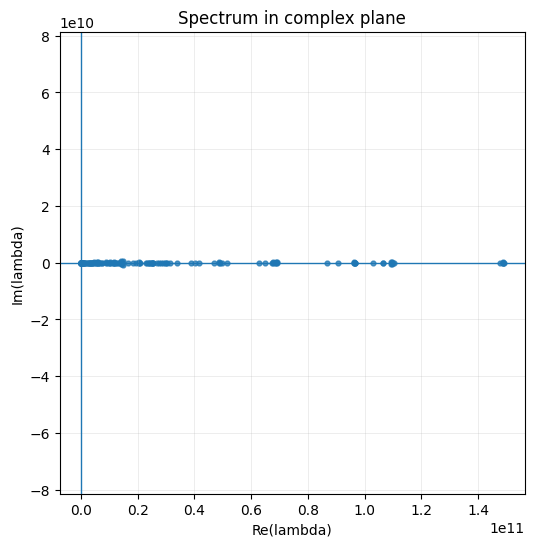

residual is: 0.0002006909124392858
residual is: 0.00022062204854590822
residual is: 0.00016910352841274724
residual is: 0.00018006622068623518
residual is: 0.00017205272639236343
residual is: 0.0001897172724236847
residual is: 0.0002253603031083018
residual is: 0.00019172392087503007
residual is: 0.0001747728105920273
residual is: 0.00016104864404966398
residual is: 0.00022218714427482998
residual is: 0.0002031169407087728
residual is: 0.00017468150134291091
residual is: 0.00016433879483695397
residual is: 0.00019893565323266332
residual is: 0.00020180669169324094
residual is: 0.0001719623220671995
residual is: 0.00023117290513317856
residual is: 0.00019747356307327807
residual is: 0.0002037396713526603
residual is: 0.00017305829584865088
residual is: 0.00017805493060505187
residual is: 0.00018829728785658053
residual is: 0.00018036529296858067
residual is: 0.00019683529677846923
residual is: 0.00020624882893061804
residual is: 0.00018170695568606762
residual is: 0.00017071740796968015

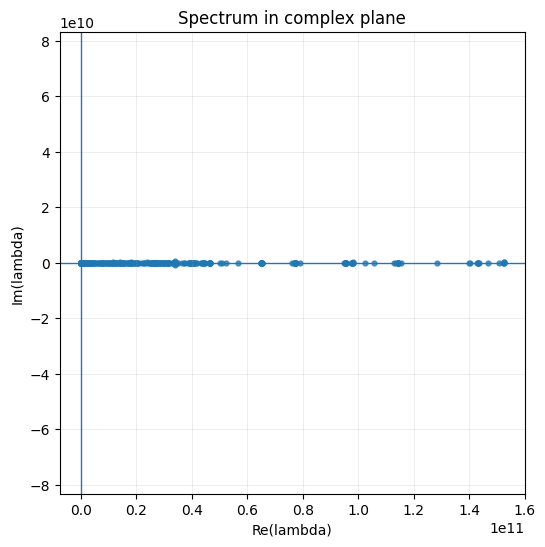

residual is: 0.00044442420970941543
residual is: 0.000469394282010283
residual is: 0.0004039286006368888
residual is: 0.0004208689216735194
residual is: 0.00042129781522806816
residual is: 0.0005392445436267087
residual is: 0.00040713314484533067
residual is: 0.0004101074669310141
residual is: 0.00040950585087540643
residual is: 0.000457689293475054
residual is: 0.00040046013141414286
residual is: 0.0004541651460844558
residual is: 0.0004613011927462583
residual is: 0.0004569428364072164
residual is: 0.00043503243314154235
residual is: 0.000392961319239513
residual is: 0.0003864682645964517
residual is: 0.00048528111603247796
residual is: 0.00046427989373723066
residual is: 0.0004267075200148498
residual is: 0.00039981973342097075
residual is: 0.0004347203134460147
residual is: 0.0004124537140614501
residual is: 0.00043695255676919276
residual is: 0.0003933592014506411
residual is: 0.00046852922885622865
residual is: 0.00040794317937179294
residual is: 0.0004183119664974478
residual is

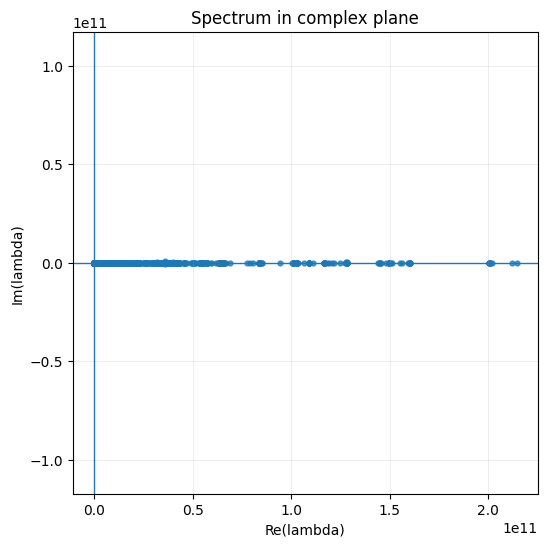

residual is: 0.000914708713395431
residual is: 0.0009708346490857824
residual is: 0.001023235085208212
residual is: 0.0010952920060402149
residual is: 0.0009811443124824147
residual is: 0.0009677691913622425
residual is: 0.000862496998310037
residual is: 0.001118818672728478
residual is: 0.0010509468911575068
residual is: 0.0010513282205084314
residual is: 0.0009362538456254389
residual is: 0.0009716641092864048
residual is: 0.0010646042944142192
residual is: 0.0010149443178719536
residual is: 0.0008199169324912245
residual is: 0.0009112211541054755
residual is: 0.0010536971414199145
residual is: 0.0009854490955832772
residual is: 0.0011324636213812576
residual is: 0.0010352608685153097
residual is: 0.000991625597858987
residual is: 0.0009059426025740682
residual is: 0.0008254060306182553
residual is: 0.0009732538673999583
residual is: 0.000902094311377567
residual is: 0.0009437651657438254
residual is: 0.0010338059009471685
residual is: 0.0009699140619111033
residual is: 0.00098172592

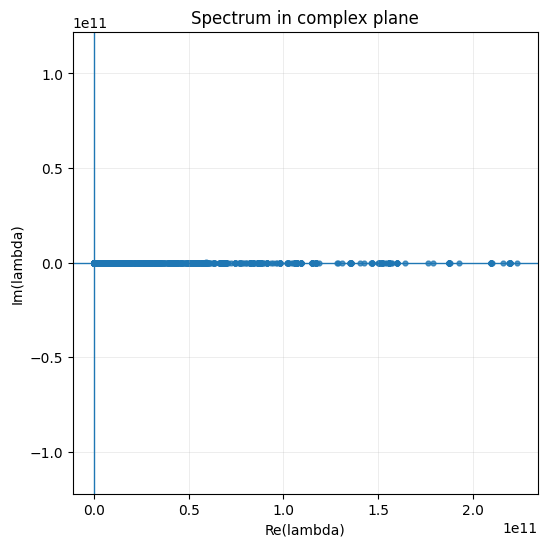

residual is: 0.0037282182637501087
residual is: 0.003336814270558855
residual is: 0.003505771758052757
residual is: 0.00314497486674089
residual is: 0.003547883234179033
residual is: 0.0037685315870510916
residual is: 0.0044353969266978975
residual is: 0.003393563110806011
residual is: 0.0033690333324504053
residual is: 0.0035852538599821645
residual is: 0.0039410984561711266
residual is: 0.0032780419356172527
residual is: 0.0035435107388170745
residual is: 0.00345207619741811
residual is: 0.003500585339782725
residual is: 0.0031844470520871883
residual is: 0.0037706007224930747
residual is: 0.0035039197927613217
residual is: 0.0037932307833684316
residual is: 0.003524175219825879
residual is: 0.003513434939311527
residual is: 0.003917430140858092
residual is: 0.0035878008144169206
residual is: 0.0037018865901397332
residual is: 0.004115477050784394
residual is: 0.0038787365085656434
residual is: 0.0036758139927487213
residual is: 0.0029644079951758953
residual is: 0.003394826096501882

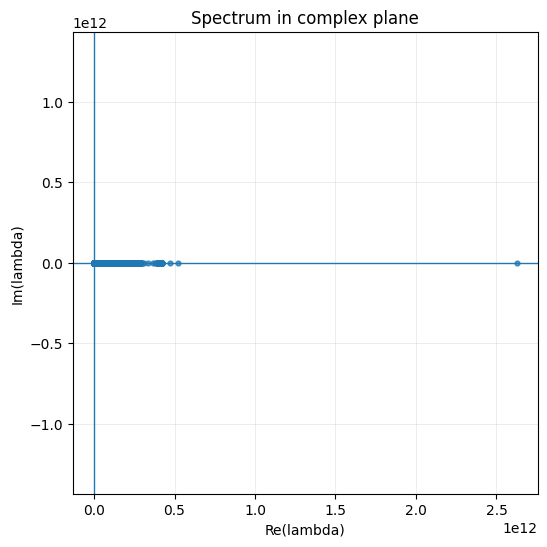

residual is: 0.012047435924279953
residual is: 0.011834032566699982
residual is: 0.01337580188620398
residual is: 0.012439934437914682
residual is: 0.013932222173392747
residual is: 0.014138136085923472
residual is: 0.011701080598122882
residual is: 0.01155415834830838
residual is: 0.013438708778800528
residual is: 0.01251233187336112
residual is: 0.012281458919792574
residual is: 0.012444088536647123
residual is: 0.012566641580476542
residual is: 0.012842857108659712
residual is: 0.011659246071480318
residual is: 0.01462321500680487
residual is: 0.01160144217837556
residual is: 0.011809742352220699
residual is: 0.012315906328565326
residual is: 0.012672547804739205
residual is: 0.012763072152964508
residual is: 0.012285587443627358
residual is: 0.010312619505305968
residual is: 0.011728519381949387
residual is: 0.011016601226045872
residual is: 0.012542517634435063
residual is: 0.011386678247992698
residual is: 0.010785835301986929
residual is: 0.012825708390583382
residual is: 0.0115

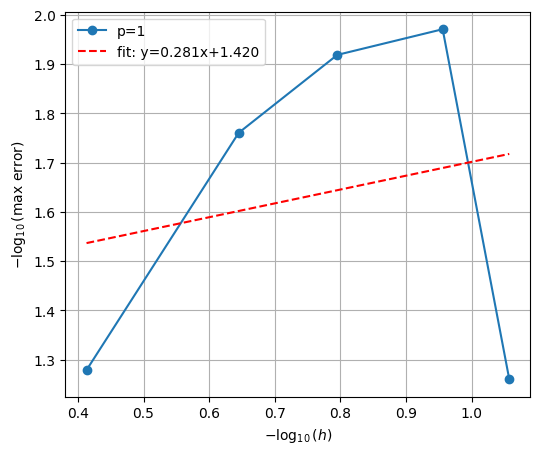

In [41]:
key = 100
np.random.seed(key)

NN = [15,30,50,80,200]
BC = [25,50,100,200,400]
tau = 1e-3
T = 0.2 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

RR = [1e-12,1e-12,1e-12,1e-13,1e-15]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = BC[qi]
    overlap = 0.2
    # generate points
    X_inner, X_boundary, C, R ,_ = generator_points_2d_overlap(
    N_patch_grid, N_local_per_patch, N_boundary, overlap, False)
    ptch = {
    "C": C,
    "R": R
    }
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 2
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    U,LBDF1,LBDF2,LI = rfm_fd_pum_poly_solve_heat_scaled(ptch, X, Yin, Yb,out_n, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme="BDF2")
    error = np.max(np.abs(U - u_true))
    e = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label='p=1')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


In [34]:
key = 100
np.random.seed(key)

NN = [15,30,50,80,200]
BC = [25,50,100,200,400]

tau = 1e-3
T = 0.2 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

RR = [1e-12,1e-12,1e-12,1e-14,1e-14]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = BC[qi]
    overlap = 0.2
    # generate points
    X_inner, X_boundary, C, R ,_ = generator_points_2d_overlap(
    N_patch_grid, N_local_per_patch, N_boundary, overlap, False)
    ptch = {
    "C": C,
    "R": R
    }
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 3
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    U,LBDF1,LBDF2,LI = rfm_fd_pum_poly_solve_heat_scaled(ptch, X, Yin, Yb,out_n, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme="BDF2")
    error = np.max(np.abs(U - u_true))
    e = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=15
Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 19
removed patches: 6
patch nX min/mean/max: 4 / 17.58 / 38
X_inner: 128
X_boundary: 25
cover X_inner min/mean/max: 1 2.61 4 uncovered: 0
cover X_all min/mean/max: 1 2.52 4 uncovered: 0
X.shape 153


TypeError: rfm_fd_pum_poly_solve_heat_scaled() missing 1 required positional argument: 'order'

In [35]:
key = 100
np.random.seed(key)

NN = [15,30,50,80,200]
BC = [25,50,100,200,400]

tau = 1e-3
T = 0.2 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

RR = [1e-8,1e-12,1e-12,1e-12,1e-15]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = BC[qi]
    overlap = 0.2
    # generate points
    X_inner, X_boundary, C, R ,_ = generator_points_2d_overlap(
    N_patch_grid, N_local_per_patch, N_boundary, overlap, False)
    ptch = {
    "C": C,
    "R": R
    }
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 4
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    U,LBDF1,LBDF2,LI = rfm_fd_pum_poly_solve_heat_scaled(ptch, X, Yin, Yb, out_n, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme="BDF2")
    error = np.max(np.abs(U - u_true))
    e = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=15
Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 19
removed patches: 6
patch nX min/mean/max: 4 / 17.58 / 38
X_inner: 128
X_boundary: 25
cover X_inner min/mean/max: 1 2.61 4 uncovered: 0
cover X_all min/mean/max: 1 2.52 4 uncovered: 0
X.shape 153


TypeError: rfm_fd_pum_poly_solve_heat_scaled() missing 1 required positional argument: 'order'

In [36]:
markers = ['o', 's', '^', 'D', 'v']  
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
labels = ['p=0', 'p=1', 'p=2', 'p=3','p=4']
plt.figure(figsize=(8, 6))

for i in range(5):
    h = H[i, :]
    e = E[i, :]
    log_h = np.log(h)
    log_e = np.log(e)
    slope, intercept = np.polyfit(log_h, log_e, 1)
    fit_e = np.exp(intercept) * h**slope
    plt.loglog(h, e, markers[i], color=colors[i], label=f'{labels[i]}')
    plt.loglog(h, fit_e, linestyle='--', color=colors[i], alpha=0.7)
    plt.plot(h, e, marker=markers[i], color=colors[i], linestyle='-')

plt.xlabel('Step size (h)', fontsize=12)
plt.ylabel('Relative $l_2$ Error', fontsize=12)
# plt.title('Convergence Study: Least Squares Fit', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
# plt.savefig('./heat_rfmfd_pu_p=0123_convergence_scatter.eps', bbox_inches='tight')
plt.show()

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value


/tmp/ipykernel_2751616/728249469.py:9: RuntimeWarning: divide by zero encountered in log
  log_h = np.log(h)
/tmp/ipykernel_2751616/728249469.py:10: RuntimeWarning: divide by zero encountered in log
  log_e = np.log(e)
/home/chengwu/.conda/envs/py312/lib/python3.12/site-packages/numpy/lib/_polynomial_impl.py:674: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


LinAlgError: SVD did not converge in Linear Least Squares

<Figure size 800x600 with 0 Axes>

$Operator learning$

In [ ]:
import time
import torch
import numpy as np
import torch.nn as nn
from scipy.io import loadmat
import scipy.sparse as sp
from scipy.spatial import cKDTree, distance
from scipy.linalg import cholesky
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

# def vandercorput(n, base):
#     """
#     Vectorized van der Corput for n = array-like nonnegative integers and given base.
#     Returns array of same shape as n with values in [0,1).
#     """
#     n = np.asarray(n, dtype=np.int64)
#     # compute digits for each n by repeated division
#     out = np.zeros_like(n, dtype=np.float64)
#     denom = base
#     current = n.copy()
#     while np.any(current > 0):
#         digit = current % base
#         out += digit / denom
#         current = current // base
#         denom *= base
#     return out

# def halton_sequence(N, dim):
#     """
#     Generate first N points of Halton sequence in `dim` dimensions.
#     Uses first `dim` primes as bases.
#     Returns array shape (N, dim) with values in [0,1).
#     """
#     # small prime list sufficient for moderate dim
#     primes_list = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59]
#     if dim > len(primes_list):
#         raise ValueError("Requested dimension too large for built-in primes list.")
#     bases = primes_list[:dim]
#     n_idx = np.arange(0, N, dtype=np.int64)  # n = 0..N-1
#     H = np.empty((N, dim), dtype=np.float64)
#     for j, b in enumerate(bases):
#         H[:, j] = vandercorput(n_idx, b)
#     return H

# def generator_points_star(N_patch_grid,
#                      N_local_per_patch,
#                      N_boundary,
#                      R_ptch,
#                      mode="c-rbf-pum"):
#     """
#     Generate points on a star-shaped region and patch covering.

#     Parameters
#     ----------
#     N_patch_grid : int
#         number of patches per dimension (grid)
#     N_local_per_patch : int
#         target local points per patch (used as halton sample size per patch)
#     N_boundary : int
#         number of boundary points
#     R_ptch : float
#         patch radius
#     mode : str
#         "c-rbf-pum" or "ls-rbf-pum"

#     Returns
#     -------
#     X_inner : ndarray (N_x,2)
#         concatenated interior/source points
#     X_boundary : ndarray (N_boundary,2)
#         boundary points (uniform in theta)
#     ptch : dict
#         {'C': array(P,2), 'R': array(P,) } patch centers and radii
#     grid_eval : ndarray (N_eval,2)
#         evaluation/prediction points (depends on mode)
#     """
#     # -------------------------
#     # 1. star region radial function
#     def r_max_func(theta):
#         return 2.0 * (0.7 + 0.12 * (np.sin(6*theta) + np.sin(3*theta)))

#     # vector theta for plotting / sampling
#     theta_plot = np.linspace(0.0, 2*np.pi, 1000, endpoint=False)
#     r_plot = r_max_func(theta_plot)
#     x_plot = r_plot * np.cos(theta_plot)
#     y_plot = r_plot * np.sin(theta_plot)

#     x_min, x_max = x_plot.min(), x_plot.max()
#     y_min, y_max = y_plot.min(), y_plot.max()
#     R_container = r_plot.max()

#     # helper: is point(s) inside star region (vectorized)
#     def is_inside_star(x, y):
#         x = np.asarray(x)
#         y = np.asarray(y)
#         r = np.sqrt(x**2 + y**2)
#         theta = np.arctan2(y, x)
#         theta = np.where(theta < 0, theta + 2*np.pi, theta)
#         r_limit = r_max_func(theta)
#         TOL = 1e-12
#         return r <= (r_limit + TOL)

#     # -------------------------
#     # 2. Patch grid parameters
#     Domain_size = max(x_max - x_min, y_max - y_min)
#     num_patches_1D = int(N_patch_grid)
#     # avoid division by zero when Domain_size small
#     if num_patches_1D <= 1:
#         del_param = 0.0
#     else:
#         del_param = (num_patches_1D - Domain_size / R_ptch) / (num_patches_1D - 1)
#     patch_spacing = 2 * R_ptch * (1 - del_param)

#     # create center grid in bounding square [Grid_min, Grid_max]^2
#     Grid_min = min(x_min, y_min)
#     Grid_max = max(x_max, y_max)
#     Cx = np.linspace(Grid_min, Grid_max, num_patches_1D)
#     Cy = np.linspace(Grid_min, Grid_max, num_patches_1D)
#     Cxv, Cyv = np.meshgrid(Cx, Cy)
#     C_all = np.column_stack([Cxv.ravel(), Cyv.ravel()])
#     R_all = R_ptch * np.ones((C_all.shape[0],), dtype=np.float64)

#     # For each candidate patch, sample its circle boundary points and check overlap
#     theta_circ = theta_plot  # reuse dense sample
#     # build for all centers: shifted circle coordinates
#     # shape (num_centers, n_theta)
#     bc_x = C_all[:, 0:1] + R_all[:, None] * np.cos(theta_circ)[None, :]
#     bc_y = C_all[:, 1:] + R_all[:, None] * np.sin(theta_circ)[None, :]

#     # Determine which patch has any boundary point inside the star region
#     # is_inside_star accepts arrays; compute over all boundary samples
#     inside_flags = is_inside_star(bc_x, bc_y)  # shape (num_centers, n_theta)
#     id_keep = np.where(inside_flags.sum(axis=1) > 0)[0]

#     C_kept = C_all[id_keep, :]
#     R_kept = R_all[id_keep]
#     ptch = {'C': C_kept, 'R': R_kept}
#     P = C_kept.shape[0]

#     # -------------------------
#     # 3. Generate RBF center points per patch (Halton sampling in polar coords)
#     X_inner_points = []
#     grid_eval_points = []  # for c-rbf-pum mode
#     # we will use exactly N_local_per_patch halton samples per patch (as in your adjusted code)
#     N_generate = int(N_local_per_patch)
#     # for LS mode, generate global evaluation grid if requested
#     if mode == "ls-rbf-pum":
#         # create a dense grid that covers the bounding box and then trim to star region
#         n_grid = int(round(np.sqrt(P * N_generate) * 1.5))
#         if n_grid < 2:
#             n_grid = 2
#         x_eval = np.linspace(x_min, x_max, n_grid)
#         y_eval = np.linspace(y_min, y_max, n_grid)
#         Xg, Yg = np.meshgrid(x_eval, y_eval)
#         grid_pts = np.column_stack([Xg.ravel(), Yg.ravel()])
#         mask_grid = is_inside_star(grid_pts[:, 0], grid_pts[:, 1])
#         grid_eval_all = grid_pts[mask_grid, :]
#     else:
#         grid_eval_all = np.empty((0, 2))

#     # Halton base samples for polar mapping (u,v)
#     H = halton_sequence(N_generate, 2)  # (N_generate, 2)
#     u = H[:, 0]
#     v = H[:, 1]

#     for i in range(P):
#         C = C_kept[i, :]
#         R = R_kept[i]
#         theta_local = 2.0 * np.pi * u  # (N_generate,)
#         r_local = np.sqrt(v) * R
#         x_local = r_local * np.cos(theta_local) + C[0]
#         y_local = r_local * np.sin(theta_local) + C[1]
#         if mode == "c-rbf-pum":
#             inside_mask = is_inside_star(x_local, y_local)
#             X_candidate = np.column_stack([x_local[inside_mask], y_local[inside_mask]])
#             # keep all that are inside; you may trim to desired count elsewhere
#             X_inner_points.append(X_candidate)
#             grid_eval_points.append(X_candidate)
#         elif mode == "ls-rbf-pum":
#             # do not clip to patch by star region (as MATLAB's ls mode keeps all)
#             X_candidate = np.column_stack([x_local, y_local])
#             X_inner_points.append(X_candidate)
#             # N_total in MATLAB set to P * N_generate; we follow that
#         else:
#             raise ValueError("Unrecognized mode: {}".format(mode))

#     if len(X_inner_points) > 0:
#         X_inner = np.vstack([arr for arr in X_inner_points if arr.shape[0] > 0])
#     else:
#         X_inner = np.empty((0, 2))

#     if mode == "c-rbf-pum":
#         # grid_eval collects retained candidates
#         if len(grid_eval_points) > 0:
#             grid_eval = np.vstack([arr for arr in grid_eval_points if arr.shape[0] > 0])
#         else:
#             grid_eval = np.empty((0, 2))
#     else:
#         grid_eval = grid_eval_all

#     # -------------------------
#     # 4. Generate boundary points (uniform in theta)
#     theta_bnd = np.linspace(0.0, 2*np.pi, N_boundary, endpoint=False)
#     r_bnd = r_max_func(theta_bnd)
#     x_bnd = r_bnd * np.cos(theta_bnd)
#     y_bnd = r_bnd * np.sin(theta_bnd)
#     X_boundary = np.column_stack([x_bnd, y_bnd])

#     # also return boundary curve for plotting convenience
#     boundary_curve = np.column_stack([x_plot, y_plot])

#     return X_inner, X_boundary, ptch, grid_eval, boundary_curve

# # --------------------------
# # Plotting wrapper
# # --------------------------
# def plot_generator_points(X_inner, X_boundary, ptch, grid_eval, boundary_curve, figsize1=(7,6), figsize2=(7,6)):
#     """
#     Draw two figures similar to MATLAB version:
#     - Figure 1: patch coverage, interior points, boundary points, region boundary
#     - Figure 2: prediction grid and boundary
#     """
#     C = ptch['C']
#     R = ptch['R']
#     P = C.shape[0]
#     theta_circ = np.linspace(0, 2*np.pi, 200)

#     # Figure 1
#     plt.figure(figsize=figsize1)
#     ax = plt.gca()
#     # patch circles (dashed)
#     for i in range(P):
#         x_circ = C[i,0] + R[i] * np.cos(theta_circ)
#         y_circ = C[i,1] + R[i] * np.sin(theta_circ)
#         ax.plot(x_circ, y_circ, linestyle=':', color='k', linewidth=1.2)
#         ax.plot(C[i,0], C[i,1], marker='x', color='g', markersize=6)
#     # region boundary
#     ax.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
#     # interior points
#     if X_inner.shape[0] > 0:
#         ax.scatter(X_inner[:,0], X_inner[:,1], s=10, c='b', marker='.', label='Interior points')
#     # boundary points
#     if X_boundary.shape[0] > 0:
#         ax.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary points')
#     ax.set_aspect('equal', 'box')
#     ax.set_title('Patch Coverage and Node Distribution in the Star-Shaped Domain', fontsize=12)
#     ax.set_xlabel('x')
#     ax.set_ylabel('y')
#     ax.legend()
#     ax.grid(True)
#     plt.tight_layout()

#     # Figure 2: prediction grid
#     plt.figure(figsize=figsize2)
#     ax2 = plt.gca()
#     ax2.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
#     if grid_eval is not None and grid_eval.shape[0] > 0:
#         ax2.scatter(grid_eval[:,0], grid_eval[:,1], s=8, c='r', marker='.', label='Evaluation Points')
#     if X_boundary.shape[0] > 0:
#         ax2.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary Points')
#     ax2.set_aspect('equal', 'box')
#     ax2.set_title('Evaluation Point Distribution in the Star-Shaped Domain', fontsize=12)
#     ax2.set_xlabel('x')
#     ax2.set_ylabel('y')
#     ax2.legend()
#     ax2.grid(True)
#     plt.tight_layout()
#     plt.show()

class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = True) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        output = self.input_layer(x)
        output = torch.sin(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
	
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight.data)
                if m.bias is not None:
                    # nn.init.normal_(m.bias, mean=0.0, std=1)
                    # m.bias.data.zero_()
                    nn.init.uniform_(m.bias, -0, 0)




In [ ]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.linalg import spsolve
from scipy.linalg import cholesky, solve_triangular

def relative_l2(u_pred, u_true):
# Relative L2 error between two (N, 1) tensors.
    eps = 0
    def to_numpy(u):
        if sp.issparse(u):
            u = u.toarray()
        else:
            u = np.asarray(u)
        return u.reshape(-1) # flatten to (N,)
    u_pred,u_true = to_numpy(u_pred),to_numpy(u_true)
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + eps)


def build_wls_solver(A, reg=1e-12):
    """
    Precompute WLS system for repeated RHS solves.
    """

    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")

    A = A.tocsr()
    M, N = A.shape

    # -------------------------------------------------
    # weight (computed ONCE)
    # -------------------------------------------------
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    w = 10.0 / (row_max + 1e-12)

    W = sp.diags(w, format='csr')

    # -------------------------------------------------
    # precompute matrices
    # -------------------------------------------------
    Aw = W @ A
    AtA = Aw.T @ Aw + reg * sp.eye(N, format='csr')

    # factorization (FAST SOLVE)
    solver = spla.factorized(AtA.tocsc())

    # -------------------------------------------------
    # return closure
    # -------------------------------------------------
    def solve(RHS):
        """
        RHS: (M,K)
        """
        RHS = np.asarray(RHS, dtype=np.float64)

        if RHS.ndim == 1:
            RHS = RHS[:, None]

        # weighted RHS
        RHSw = w[:, None] * RHS

        Atb = Aw.T @ RHSw
        x = solver(Atb)

        if x.ndim == 1:
            x = x[:, None]

        return x

    return solve

def test_solver(LBDF1, LBDF2, LI,
                f_func, g_func, u0_func,
                Yin, Yb, t, tau,
                scheme="BDF2"):
    """
    Multi-batch heat solver using unified WLS (row-max weighted least squares).

    Returns
    -------
    U : ndarray, shape (n_batch, M, NT)
    """

    # --------------------------------------------------
    # geometry
    # --------------------------------------------------
    Y = np.concatenate([Yin, Yb], axis=0)
    M = Y.shape[0]
    M2 = Yb.shape[0]
    M1 = M - M2
    NT = t.shape[0]

    # --------------------------------------------------
    # data
    # --------------------------------------------------
    f_val = f_func(Yin[:, 0:1], Yin[:, 1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:, 0:1], Yb[:, 1:2], t) if callable(g_func) else g_func

    u0 = u0_func(Y[:, 0:1], Y[:, 1:2]) if callable(u0_func) else u0_func
    u0 = np.asarray(u0, dtype=np.float64)

    # --------------------------------------------------
    # batch handling
    # --------------------------------------------------
    if u0.ndim == 1:
        u0 = u0[:, None]

    n_batch = u0.shape[1]

    solve_LBDF1 = build_wls_solver(LBDF1, reg=1e-12)
    solve_LBDF2 = build_wls_solver(LBDF2, reg=1e-12)
    solve_LI    = build_wls_solver(LI, reg=1e-12)

    # --------------------------------------------------
    # initial solve (LI)
    # --------------------------------------------------
    alpha_0 = solve_LI(u0)

    # --------------------------------------------------
    # storage
    # --------------------------------------------------
    U = np.zeros((n_batch, M, NT), dtype=np.float64)
    U[:, :, 0] = u0.T
    U[:, M1:, :] = g_val[None, :, :]

    reg = 1e-12

    # ==================================================
    # BDF1
    # ==================================================
    if scheme == "BDF1":

        for i in range(0, NT - 1):

            rhs_int = LI @ alpha_0
            if rhs_int.ndim == 1:
                rhs_int = rhs_int[:, None]

            rhs = rhs_int[:M1, :] + tau * f_val[:, i + 1:i + 2]

            RHS = np.vstack([
                rhs,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_1, _ = solve_LBDF1(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_1).T

            alpha_0 = alpha_1

        return U
    # ==================================================
    # BDF2
    # ==================================================
    elif scheme == "BDF2":

        # -----------------------------
        # step 1: initial BDF1 step
        # -----------------------------
        rhs_int = LI[:M1, :] @ alpha_0 + tau * f_val[:, 1:2]

        RHS = np.vstack([
            rhs_int,
            np.repeat(g_val[:, 1:2], n_batch, axis=1)
        ])

        alpha_1 = solve_LBDF1(RHS)

        U[:, :M1, 1] = (LI[:M1, :] @ alpha_1).T

        # -----------------------------
        # BDF2 time loop
        # -----------------------------
        for i in range(1, NT - 1):

            rhs_int = (
                LI[:M1, :] @ (4 * alpha_1 - alpha_0)
                + 2 * tau * f_val[:, i + 1:i + 2]
            )

            RHS = np.vstack([
                rhs_int,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_2 = solve_LBDF2(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_2).T
            U[:, M1:, i + 1] = g_val[:, i + 1]

            alpha_0 = alpha_1
            alpha_1 = alpha_2

        return U

    else:
        raise ValueError("Unsupported scheme. Use 'BDF1' or 'BDF2'.")
    


In [ ]:
### rewrite the solver for weighted QR
import scipy.sparse as sp
import scipy.sparse.linalg as spla

def rfm_fd_pum_poly_solve_heat_QR(
        ptch, X, Yin, Yb, t, tau,
        f_func, g_func, u0_func,
        Phi, reg, order,
        scheme="BDF2"
):
    """
    PUM-RFM-FD heat solver with pre-factorized weighted least squares.

    Returns
    -------
    U      : (M, NT)
    LBDF1  : sparse matrix
    LBDF2  : sparse matrix
    LI     : sparse matrix
    """
    patch_C = ptch['C']
    patch_R = ptch['R']
    Nc = patch_C.shape[0]
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]
    W_matrix,grad_Wx, grad_Wy, lap_W = shepard_weights_with_derivatives(Y, patch_C, patch_R)  # M x Nc
    # Construct sparse L matrix
    LBDF2 = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    LBDF1 = lil_matrix((M, N))
    LBDF3 = lil_matrix((M, N))
    LBDF4 = lil_matrix((M, N))
    # Construct RHS
    RHS = np.zeros((M,1))
    # Precompute RHS
    f_val = f_func(Yin[:,0:1], Yin[:,1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:,0:1], Yb[:,1:2], t) if callable(g_func) else g_func
    u0 = u0_func(Y[:,0:1], Y[:,1:2]) if callable(u0_func) else u0_func[:, None]

    
    # --------------------------
    # 预处理邻域索引（vectorized）
    # --------------------------
    dist_XC = cdist(X, patch_C)      # (N, Nc)
    # dist_Y1C = cdist(Yin, patch_C)   # (M1, Nc)
    # dist_Y2C = cdist(Yb, patch_C)    # (M2, Nc)
    dist_YC = cdist(Y, patch_C)      # (M, Nc)
    # --------------------------------------------------
    start = time.time()
    for i in range(Nc):
        idx_X = np.where(dist_XC[:, i] <= patch_R[i])[0]
        idx_Y = np.where(dist_YC[:, i] <= patch_R[i])[0]
        idx_Yin = idx_Y[idx_Y < M1]
        idx_Yb = idx_Y[idx_Y >= M1]

        Mk,Mk_1 = idx_Y.shape[0],idx_Yin.shape[0]
        Yk_in,Yk_b = Y[idx_Yin],Y[idx_Yb]
        Yk = np.concatenate([Yk_in,Yk_b], axis = 0)
        nj = idx_X.shape[0]
        RHS_lap = np.zeros((nj+Norder,Mk_1)) # only need interior points
        RHS_ide = np.ones((nj+Norder,Mk))
        AP = np.zeros((nj+Norder,nj+Norder))
        P = np.ones((nj,Norder))

        Z = X[idx_X] # (nj,2)
        # print(f"Patch {i+1}/{Nc}: nj={nj}, Mk={Mk}, Mk_1={Mk_1}")

        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (nj,nj)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (nj,nj)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_YX, lap_phi, grad_y  = laplacian_phi_wrt_y(Phi, Yk, Z) # (Mk,nj)
        grad_phi_x = grad_y[:, :, 0].T  # (nj,Mk)
        grad_phi_y = grad_y[:, :, 1].T  # (nj,Mk) (Mk,nj) # if not Yk, storage will be too large.
        # AP
        P = poly2D(Z, order)  # (nj,Norder)
        AP[:nj,:] = np.concatenate([Phi_jj,P], axis = 1) # (nj,nj+Norder)
        AP[nj:,:-Norder] = P.T # (Norder,nj)
        ## --- RHS_lap(Yin), RHS_ide(Y)
        lap_p = laplacian_poly2D(order,Yk_in) # (Norder, Mk_1)
        p_y = poly2D(Yk, order).T       # (Mk,Norder).T = (Norder,Mk)
        lap_phi = lap_phi[:Mk_1,:]      # (Mk,nj) --> (Mk_1,nj)
        RHS_lap[:nj,:] = lap_phi.T      # (nj, Mk_1), Yk_in
        RHS_lap[nj:,:] = lap_p          # (Norder, Mk_1)
        RHS_ide[:nj,:] = phi_YX.T       # (Mk,nj).T 
        RHS_ide[nj:,:] = p_y            # (Norder, Mk)
        # --- RHS_gra_x(Yin), RHS_gra_z(Yin)
        p_x,p_z = gradient_poly2D(order, Yk_in)  # (Norder,Mk_1)
        RHS_gra_x = np.zeros((nj+Norder,Mk_1))  # (nj+Norder, Mk_1)
        RHS_gra_z = np.zeros((nj+Norder,Mk_1))  # (nj+Norder, Mk_1)
        RHS_gra_x[:nj,:] = grad_phi_x[:,:Mk_1]     # (nj, Mk_1)
        RHS_gra_z[:nj,:] = grad_phi_y[:,:Mk_1]     # (nj, Mk_1)
        RHS_gra_x[nj:,:] = p_x               # (Norder, Mk_1)
        RHS_gra_z[nj:,:] = p_z               # (Norder, Mk_1)

        # --- w_lap, w_ide
        AP = AP + reg * np.eye(nj + Norder)

        LU = lu_factor(AP)
        RHS_all = np.concatenate([RHS_ide, RHS_lap, RHS_gra_x, RHS_gra_z],axis=1)
        W_all = lu_solve(LU, RHS_all)
        w_ide    = W_all[:, 0:Mk]                # (nj + Norder, Mk)
        w_lap    = W_all[:, Mk:Mk+Mk_1]          # (nj + Norder, Mk_1)
        w_grad_x = W_all[:, Mk+Mk_1:Mk+2*Mk_1]   # (nj + Norder, Mk_1)
        w_grad_z = W_all[:, Mk+2*Mk_1:]          # (nj + Norder, Mk_1)

        # w_ide = lu_solve(LU, RHS_ide)   # (nj + Norder, Mk)
        # w_lap = lu_solve(LU, RHS_lap)   # (nj + Norder, Mk_1)
        # w_grad_x = lu_solve(LU, RHS_gra_x)   # (nj + Norder, Mk_1)
        # w_grad_z = lu_solve(LU, RHS_gra_z)   # (nj + Norder, Mk_1)
        # --- Shepard weight. W_matrix,grad_Wx, grad_Wy, lap_W , M x Nc
        win = W_matrix[idx_Yin,i][None, :]    # (1, Mk_1)
        win_gradx = grad_Wx[idx_Yin,i][None, :]  # (1, Mk_1)
        win_gradz = grad_Wy[idx_Yin,i][None, :]  # (1, Mk_1)
        win_lap = lap_W[idx_Yin,i][None, :]      # (1, Mk_1)
        Laplace = (2 * win_gradx * w_grad_x[:nj,:Mk_1] + 2 * win_gradz * w_grad_z[:nj,:Mk_1] + win * w_lap[:nj,:Mk_1] + win_lap * w_ide[:nj,:Mk_1])  # (nj, Mk_1)
        I = win * w_ide[:nj,:Mk_1]          # (nj, Mk_1)
        # --- boundary condtion
        wbc = W_matrix[idx_Yb,i][None, :]  # (1, Mk_2)
        Op_bc = wbc * w_ide[:nj,Mk_1:]        # (nj, Mk_2)
        # --- LI 
        wvec = W_matrix[idx_Y, i][None, :]    # (1, Mk)
        IDE = wvec * w_ide[:nj,:]             # (nj,Mk)
        # --- Iterative Matrix
        if scheme == 'BDF2':
            LBDF1[np.ix_(idx_Yin, idx_X)] = LBDF1[np.ix_(idx_Yin, idx_X)] + (I -  tau * Laplace).T
            LBDF2[np.ix_(idx_Yin, idx_X)] = LBDF2[np.ix_(idx_Yin, idx_X)] + (3 * I - 2 * tau * Laplace).T

            LBDF1[np.ix_(idx_Yb, idx_X)] = LBDF1[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            LBDF2[np.ix_(idx_Yb, idx_X)] = LBDF2[np.ix_(idx_Yb, idx_X)] + Op_bc.T
                
            LI[np.ix_(idx_Y,idx_X)] = LI[np.ix_(idx_Y,idx_X)] + IDE.T
        elif scheme == 'BDF4':    
            LBDF1[np.ix_(idx_Yin, idx_X)] = LBDF1[np.ix_(idx_Yin, idx_X)] + (I -  tau * Laplace).T
            LBDF2[np.ix_(idx_Yin, idx_X)] = LBDF2[np.ix_(idx_Yin, idx_X)] + (3 * I - 2 * tau * Laplace).T
            LBDF3[np.ix_(idx_Yin, idx_X)] = LBDF3[np.ix_(idx_Yin, idx_X)] + (11 * I - 6 * tau * Laplace).T
            LBDF4[np.ix_(idx_Yin, idx_X)] = LBDF4[np.ix_(idx_Yin, idx_X)] + (25 * I - 12 * tau * Laplace).T

            LBDF1[np.ix_(idx_Yb, idx_X)] = LBDF1[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            LBDF2[np.ix_(idx_Yb, idx_X)] = LBDF2[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            LBDF3[np.ix_(idx_Yb, idx_X)] = LBDF3[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            LBDF4[np.ix_(idx_Yb, idx_X)] = LBDF4[np.ix_(idx_Yb, idx_X)] + Op_bc.T
                
            LI[np.ix_(idx_Y,idx_X)] = LI[np.ix_(idx_Y,idx_X)] + IDE.T
        else:
            raise ValueError("Unsupported mode. Use 'BDF2' or 'BDF4'.")    
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    end = time.time()
    print("Compile derivative matrix time =", end - start, "seconds")
       
    U = lil_matrix((M, NT))
    U[:,0:1] = u0   # (N,1)
    U[M1:,:] = g_val
    LI = LI.tocsr()
    LBDF1 = LBDF1.tocsr()
    LBDF2 = LBDF2.tocsr()

    if M == N:
        cond_LI = np.linalg.cond(LI.todense())
        print("cond(LI) = ", cond_LI)

    # --------------------------------------------------
    # WLS pre-factorization
    # --------------------------------------------------
    solve_LI = build_wls_solver(LI, reg)
    solve_BDF1 = build_wls_solver(LBDF1, reg)
    solve_BDF2 = build_wls_solver(LBDF2, reg)

    # --------------------------------------------------
    # time stepping
    # --------------------------------------------------
    U = np.zeros((M, NT))
    U[:, 0:1] = u0
    U[M1:, :] = g_val

    alpha_0 = solve_LI(u0)

    # ---- first step BDF1
    rhs_int = u0[:M1, :] + tau * f_val[:, 1:2]
    # rhs_int = LI[:M1, :] @ alpha_0 + tau * f_val[:, 1:2]
    RHS = np.vstack([rhs_int, g_val[:, 1:2]])
    alpha_1 = solve_BDF1(RHS)

    U[:M1, 1:2] = LI[:M1, :] @ alpha_1
    U[M1:, 1:2] = g_val[:, 1:2]

    # ---- BDF2 loop
    for i in range(1, NT - 1):
        rhs_int = LI[:M1, :] @ (4 * alpha_1 - alpha_0) \
                    + 2 * tau * f_val[:, i + 1:i + 2]

        RHS = np.vstack([rhs_int, g_val[:, i + 1:i + 2]])
        alpha_2 = solve_BDF2(RHS)

        U[:M1, i + 1:i + 2] = LI[:M1, :] @ alpha_2
        U[M1:, i + 1:i + 2] = g_val[:, i + 1:i + 2]

        alpha_0 = alpha_1
        alpha_1 = alpha_2

    return U, LBDF1, LBDF2, LI


def build_wls_solver(A, reg=1e-12):
    """
    Precompute WLS system for repeated RHS solves.
    """

    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")

    A = A.tocsr()
    M, N = A.shape

    # -------------------------------------------------
    # weight (computed ONCE)
    # -------------------------------------------------
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    w = 10.0 / (row_max + 1e-12)
    W = sp.diags(w, format='csr')

    # -------------------------------------------------
    # precompute matrices
    # -------------------------------------------------
    Aw = W @ A
    AtA = Aw.T @ Aw + reg * sp.eye(N, format='csr')
    # factorization (FAST SOLVE)
    solver = spla.factorized(AtA.tocsc())
    # -------------------------------------------------
    # return closure
    # -------------------------------------------------
    def solve(RHS):
        """
        RHS: (M,K)
        """
        RHS = np.asarray(RHS, dtype=np.float64)
        if RHS.ndim == 1:
            RHS = RHS[:, None]
        # weighted RHS
        RHSw = w[:, None] * RHS
        Atb = Aw.T @ RHSw
        x = solver(Atb)
        if x.ndim == 1:
            x = x[:, None]
        return x

    return solve

def test_solver(LBDF1, LBDF2, LI,
                f_func, g_func, u0_func,
                Yin, Yb, t, tau,
                scheme="BDF2"):
    """
    Multi-batch heat solver using unified WLS (row-max weighted least squares).

    Returns
    -------
    U : ndarray, shape (n_batch, M, NT)
    """

    # --------------------------------------------------
    # geometry
    # --------------------------------------------------
    Y = np.concatenate([Yin, Yb], axis=0)
    M = Y.shape[0]
    M2 = Yb.shape[0]
    M1 = M - M2
    NT = t.shape[0]

    # --------------------------------------------------
    # data
    # --------------------------------------------------
    f_val = f_func(Yin[:, 0:1], Yin[:, 1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:, 0:1], Yb[:, 1:2], t) if callable(g_func) else g_func

    u0 = u0_func(Y[:, 0:1], Y[:, 1:2]) if callable(u0_func) else u0_func
    u0 = np.asarray(u0, dtype=np.float64)

    # --------------------------------------------------
    # batch handling
    # --------------------------------------------------
    if u0.ndim == 1:
        u0 = u0[:, None]

    n_batch = u0.shape[1]

    solve_LBDF1 = build_wls_solver(LBDF1, reg=1e-12)
    solve_LBDF2 = build_wls_solver(LBDF2, reg=1e-12)
    solve_LI    = build_wls_solver(LI, reg=1e-12)

    # --------------------------------------------------
    # initial solve (LI)
    # --------------------------------------------------
    alpha_0 = solve_LI(u0)

    # --------------------------------------------------
    # storage
    # --------------------------------------------------
    U = np.zeros((n_batch, M, NT), dtype=np.float64)
    U[:, :, 0] = u0.T
    U[:, M1:, :] = g_val[None, :, :]

    reg = 1e-12

    # ==================================================
    # BDF1
    # ==================================================
    if scheme == "BDF1":

        for i in range(0, NT - 1):

            rhs_int = LI @ alpha_0
            if rhs_int.ndim == 1:
                rhs_int = rhs_int[:, None]

            rhs = rhs_int[:M1, :] + tau * f_val[:, i + 1:i + 2]

            RHS = np.vstack([
                rhs,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_1, _ = solve_LBDF1(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_1).T

            alpha_0 = alpha_1

        return U
    # ==================================================
    # BDF2
    # ==================================================
    elif scheme == "BDF2":

        # -----------------------------
        # step 1: initial BDF1 step
        # -----------------------------
        rhs_int = LI[:M1, :] @ alpha_0 + tau * f_val[:, 1:2]

        RHS = np.vstack([
            rhs_int,
            np.repeat(g_val[:, 1:2], n_batch, axis=1)
        ])

        alpha_1 = solve_LBDF1(RHS)

        U[:, :M1, 1] = (LI[:M1, :] @ alpha_1).T

        # -----------------------------
        # BDF2 time loop
        # -----------------------------
        for i in range(1, NT - 1):

            rhs_int = (
                LI[:M1, :] @ (4 * alpha_1 - alpha_0)
                + 2 * tau * f_val[:, i + 1:i + 2]
            )

            RHS = np.vstack([
                rhs_int,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_2 = solve_LBDF2(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_2).T
            U[:, M1:, i + 1] = g_val[:, i + 1]

            alpha_0 = alpha_1
            alpha_1 = alpha_2

        return U
    else:
        raise ValueError("Unsupported scheme. Use 'BDF1' or 'BDF2'.")

In [ ]:
def build_wls_solver(A, reg=1e-12):
    """
    Precompute WLS system for repeated RHS solves.
    solve_A = build_wls_solver(A)
    alpha = solve_A(RHS)
    """
    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")
    A = A.tocsr()
    M, N = A.shape
    # -------------------------------------------------
    # weight (computed ONCE)
    # -------------------------------------------------
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    w = 1.0 / (row_max )
    W = sp.diags(w, format='csr')
    # -------------------------------------------------
    # precompute matrices
    # -------------------------------------------------
    Aw = W @ A
    AtA = Aw.T @ Aw + reg * sp.eye(N, format='csr')
    # factorization (FAST SOLVE)
    solver = spla.factorized(AtA.tocsc())

    # -------------------------------------------------
    # return closure
    # -------------------------------------------------
    def solve(RHS):
        """
        RHS: (M,K)
        """
        RHS = np.asarray(RHS, dtype=np.float64)

        if RHS.ndim == 1:
            RHS = RHS[:, None]

        # weighted RHS
        RHSw = w[:, None] * RHS

        Atb = Aw.T @ RHSw
        x = solver(Atb)
        if x.ndim == 1:
            x = x[:, None]
        return x
    return solve

Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 20
removed patches: 5
patch nX min/mean/max: 5 / 108.65 / 246
X_inner: 871
X_boundary: 200
cover X_inner min/mean/max: 1 2.49 4 uncovered: 0
cover X_all min/mean/max: 1 2.44 4 uncovered: 0
X.shape: 1071
Compile derivative matrix time = 0.7848572731018066 seconds
p = 3; L infity error in u_rfmfd_pu: 3.849e-01
p = 3; Relative L2 error in u_rfmfd_pu: 3.406e-02
p = 3; Relative L2 error at T time of u_rfmfd_pu: 3.012e-02
Time step 0, Relative L2 error: 8.813e-18
Time step 1, Relative L2 error: 1.164e-02
Time step 2, Relative L2 error: 1.492e-02
Time step 3, Relative L2 error: 1.868e-02
Time step 4, Relative L2 error: 2.233e-02
Time step 5, Relative L2 error: 2.571e-02
Time step 6, Relative L2 error: 2.881e-02
Time step 7, Relative L2 error: 3.161e-02
Time step 8, Relative L2 error: 3.411e-02
Time step 9, Relative L2 error: 3.634e-02
Time step 10, Relative L2 error: 3.829e-02
Time step 11, Relative L2

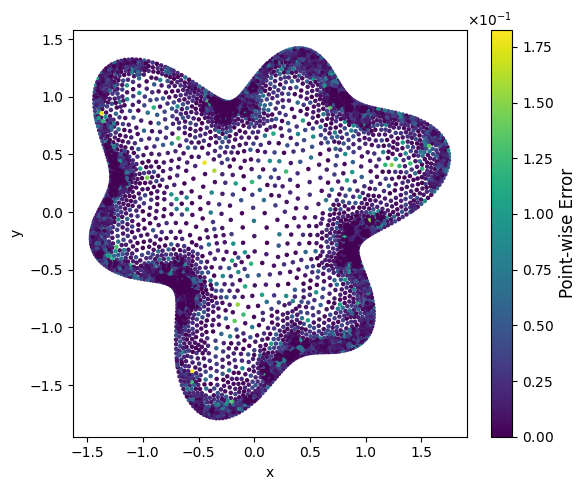

In [ ]:
import matplotlib.ticker as ticker

key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double() 

# u_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
f_func = lambda x, y, t: np.sin(x) * np.cos(y) * np.exp(-t)
g_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)


tau = 1e-3
T = 2e-1 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

data = loadmat('../data/mydata_heat_pdetool_4029_T2e-1_tau1e-3.mat')
#'u0_0', 'uT_0', 'U0_new','UT_new', 'p','in','bc'
# (M,1), (M,NT),  (M,100), (100,M,NT)
p,u0_0,uT_0,U0_new,UT_new, index_in,index_bc = data['p'],data['u0_0'],data['uT_0'],data['U0_new'],data['UT_new'],data['in'],data['bc']  # sigma = 1, l = 0.25
index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# print("UT_new.shape,", UT_new.shape) # (n_batch,M,NT)

torchdtype = torch.float64
Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]# 生成样本点已经给定
M1 = M - M2

U0_new = np.concatenate([U0_new[index_in,:],U0_new[index_bc,:]],axis=0)
testnum = 0
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
u0_func = U0_new[:,testnum]  # (M,)
order = 3
scheme = "BDF2"

reg = 1e-12
u_true = UT_new[testnum,:,:]
# print(u_true.shape) # (M,NT)
u_true = np.concatenate([u_true[index_in,:],u_true[index_bc,:]],axis=0)
# print(u_true.shape) # print(u_true.shape) # (M,NT)
# #===========================================================
# #==================== Source points X ====================
# #===========================================================
N_patch_grid = 5
N_local_per_patch = 100
N_boundary = 200
overlap = 0.2

# generate points
X_inner, X_boundary, C, R, _ = generator_points_2d_overlap(N_patch_grid, N_local_per_patch, N_boundary, overlap, False)
X = np.vstack([X_inner, X_boundary])
print(f"X.shape: {X.shape[0]}")


# # ===========================================================
U,LBDF1,LBDF2,LI = rfm_fd_pum_poly_solve_heat_QR(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme=scheme)

# print("U.shape ",U.shape) #(M,NT)
error = np.abs(U- u_true)
error = np.max(np.max(error))

print(f'p = {order}; L infity error in u_rfmfd_pu: {error:.3e}')
error_u = relative_l2(U.ravel(), u_true.ravel())
print(f'p = {order}; Relative L2 error in u_rfmfd_pu: {error_u:.3e}')

error_u = relative_l2(U[:,-1:], u_true[:,-1:])
print(f'p = {order}; Relative L2 error at T time of u_rfmfd_pu: {error_u:.3e}')

e = np.abs(U[:,-1].ravel() - u_true[:,-1].ravel())
e =np.asarray(e)

for i in range(Nt):
    err_time = relative_l2(U[:,i], u_true[:,i])
    print(f'Time step {i}, Relative L2 error: {err_time:.3e}')

plt.figure(figsize=(6,5))
print(Y[:,0].shape, Y[:,1].shape, e.shape)
sc = plt.scatter(Y[:,0], Y[:,1], c = e, cmap='viridis', s=5)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
# plt.savefig(f'./result/p={order}_error_200_size{M}.eps', bbox_inches='tight')
plt.show()


UT_new.shape  (100, 4029, 201)
After reordering, U0_new.shape  (4029, 100)
p = 3, inference time: 33.1774 秒
error_L2.shape: (100, 1), error_inf.shape: (100, 4029, 201)
p = 3, test on 100 samples. The mean of max error: 3.405986e-01, and mean of relative L2 error: 3.304598e-02
p = 3, test on 100 samples. The variance of max error: 8.436815e-03, and variance of relative L2 error: 7.358807e-05


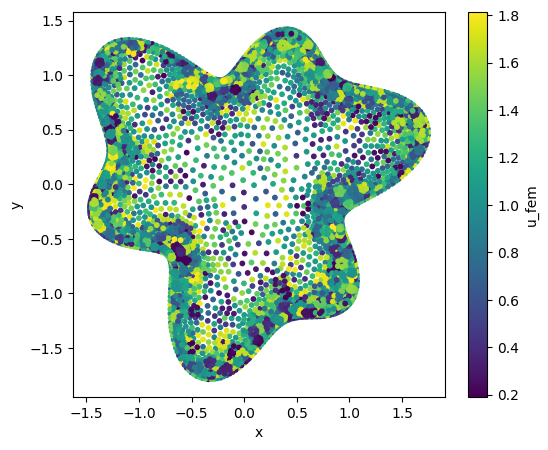

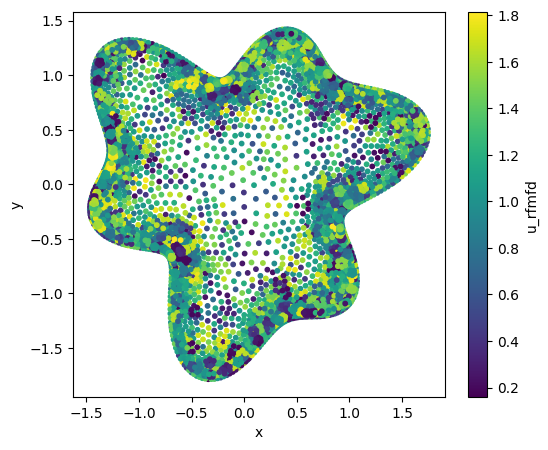

/tmp/ipykernel_102281/3681240190.py:62: UserWarning: Adding colorbar to a different Figure <Figure size 600x500 with 3 Axes> than <Figure size 600x500 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(sc)


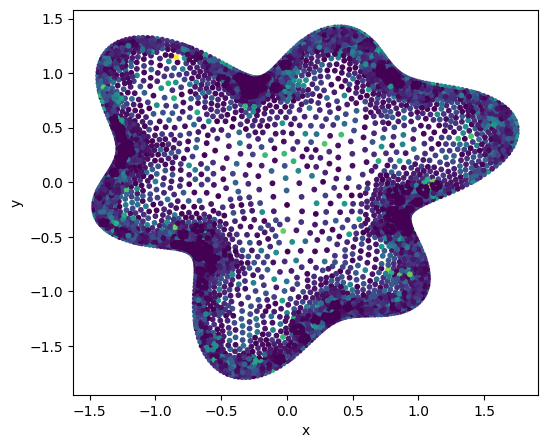

In [ ]:
import time

E_inf, E_L2 = np.zeros((100,1)),np.zeros((100,1))
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points

u_true = UT_new # (100,M,NT)
print( "UT_new.shape ", u_true.shape) 
u_true = np.concatenate([u_true[:,index_in,:],u_true[:,index_bc,:]], axis=1)

print("After reordering, U0_new.shape ", U0_new.shape) #(M,100)

start_time = time.time()
UY = test_solver(LBDF1, LBDF2, LI,
                f_func, g_func, U0_new,
                Yin, Yb, t, tau,
                scheme="BDF2") 
end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")


error_inf = np.abs(UY - u_true) # (n_batch, M, NT)
E_inf =  np.max(np.max(error_inf, axis=2), axis=1) # (n_batch, 1)
error_L2 = (np.linalg.norm(UY - u_true, axis=(1,2)) / np.linalg.norm(u_true, axis=(1,2)))[:, None] # (n_batch, 1)
print(f"error_L2.shape: {error_L2.shape}, error_inf.shape: {error_inf.shape}") #(n_batch,1), (n_batch,M,NT)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)

print(f"p = {order}, test on 100 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 100 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")

np.random.seed(30)
q = np.random.randint(0, 100)
u_true_q = u_true[q,:,-1]
UY_q = UY[q,:,-1]
error_inf_q = error_inf[q,:,-1]


plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = u_true_q, cmap='viridis', s=10)
plt.colorbar(label='u_fem')
# plt.title(f'u_fem')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/heat_rfmfd_pou_p={order}_u_fem_one_test_sample.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = UY_q, cmap='viridis', s=10)
plt.colorbar(label='u_rfmfd')
# plt.title(f'u_pred')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/heat_rfmfd_pou_p={order}_UY_one_test_sample.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c = error_inf_q, cmap='viridis', s=10)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/heat_rfmfd_pou_p={order}_error_one_test_sample.eps', bbox_inches='tight')
plt.show()



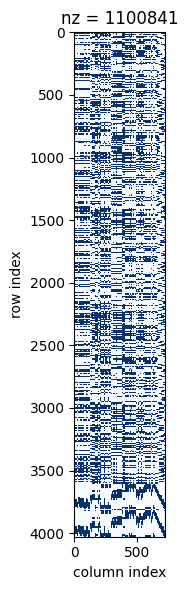

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

def spy_like_matlab(A):
    import copy
    if sp.issparse(A):
        A = A.tocsr()
        M, N = A.shape
        img = np.zeros((M, N), dtype=np.uint8)
        img[A.nonzero()] = 1
    else:
        img = (A != 0).astype(np.uint8)

    my_cmap = copy.copy(plt.cm.Blues) # or plt.cm.plasma
    my_cmap.set_bad(color='white')
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=my_cmap, origin='upper', interpolation='nearest')
    plt.xlabel('column index')
    plt.ylabel('row index')
    plt.title(f'nz = {img.sum()}')
    plt.tight_layout()
    # plt.savefig('L.eps', bbox_inches='tight')
    plt.show()
spy_like_matlab(LBDF2)

In [ ]:
for name, param in Phi.named_parameters():
    print(name, param.data)

input_layer.weight tensor([[ 0.2842],
        [-0.2967],
        [-0.1604],
        [-0.2334],
        [-0.5244],
        [-0.0046],
        [-0.2725],
        [ 0.2287],
        [-0.2161],
        [-0.0757],
        [-0.0685],
        [ 0.0640],
        [ 0.3066],
        [ 0.3625],
        [-0.0834],
        [ 0.0658],
        [ 0.3209],
        [-0.0518],
        [-0.1160],
        [-0.0907],
        [ 0.1197],
        [ 0.0820],
        [-0.0369],
        [ 0.0720],
        [ 0.0468],
        [-0.0157],
        [-0.4444],
        [ 0.1845],
        [-0.0036],
        [ 0.0795],
        [-0.2547],
        [ 0.3697],
        [-0.0387],
        [-0.0531],
        [ 0.0157],
        [-0.1510],
        [ 0.3340],
        [-0.0718],
        [ 0.1586],
        [-0.2193],
        [ 0.1426],
        [-0.0696],
        [ 0.3045],
        [ 0.1889],
        [-0.2389],
        [ 0.2154],
        [-0.2263],
        [-0.0997],
        [ 0.0391],
        [-0.2642]], device='cuda:1', dtype=torch.f